# Training the models

In [1]:
import pathlib
import remote_sensing_processor as rsp

C:\ProgramData\miniforge3\envs\geo\Lib\site-packages\ee_extra\ImageCollection\core.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Dominant tree species

First, we initialize custom top-k accuracy metrics, and then train the model.

We use SegFormer architecture and cross entropy loss.

Then we test the model on test subdataset and use it to generate a map for 2024.

In [2]:
train_dataset = {"path": "dataset_semantic.rspds", "sub": "train", "y": "species"}
val_dataset = {"path": "dataset_semantic.rspds", "sub": "val", "y": "species"}
test_dataset = {"path": "dataset_semantic.rspds", "sub": "test", "y": "species"}
map_dataset = {"path": "dataset_map.rspds", "sub": "all"}

In [3]:
import torchmetrics

a_macro_2 = torchmetrics.Accuracy(
    task="multiclass",
    num_classes=14,
    average="macro",
    ignore_index=0,
    top_k=2,
)
a_micro_2 = torchmetrics.Accuracy(
    task="multiclass",
    num_classes=14,
    average="micro",
    ignore_index=0,
    top_k=2,
)
a_macro_3 = torchmetrics.Accuracy(
    task="multiclass",
    num_classes=14,
    average="macro",
    ignore_index=0,
    top_k=3,
)
a_micro_3 = torchmetrics.Accuracy(
    task="multiclass",
    num_classes=14,
    average="micro",
    ignore_index=0,
    top_k=3,
)
a_macro_4 = torchmetrics.Accuracy(
    task="multiclass",
    num_classes=14,
    average="macro",
    ignore_index=0,
    top_k=4,
)
a_micro_4 = torchmetrics.Accuracy(
    task="multiclass",
    num_classes=14,
    average="micro",
    ignore_index=0,
    top_k=4,
)
a_macro_5 = torchmetrics.Accuracy(
    task="multiclass",
    num_classes=14,
    average="macro",
    ignore_index=0,
    top_k=5,
)
a_micro_5 = torchmetrics.Accuracy(
    task="multiclass",
    num_classes=14,
    average="micro",
    ignore_index=0,
    top_k=5,
)

In [4]:
model = rsp.semantic.train(
    train_dataset, 
    val_dataset, 
    model_file='models/segformer_species.ckpt', 
    model='SegFormer_smp',
    epochs={"max_epochs": 100, "early_stopping": True, "patience": 10}, 
    augment=True,
    loss="cross_entropy",
    metrics=[
        {"name": "accuracy_micro", "log": "verbose"},
        {"name": "accuracy_macro", "log": "step"},
        {"name": "accuracy_micro_2", "metric": a_micro_2, "log": "verbose"},
        {"name": "accuracy_macro_2", "metric": a_macro_2, "log": "step"},
        {"name": "accuracy_micro_3", "metric": a_micro_3, "log": "step"},
        {"name": "accuracy_macro_3", "metric": a_macro_3, "log": "step"},
        {"name": "accuracy_micro_4", "metric": a_micro_4, "log": "step"},
        {"name": "accuracy_macro_4", "metric": a_macro_4, "log": "step"},
        {"name": "accuracy_micro_5", "metric": a_micro_5, "log": "verbose"},
        {"name": "accuracy_macro_5", "metric": a_macro_5, "log": "step"},
        {"name": "f1_macro", "log": "epoch"},
        {"name": "f1_micro", "log": "epoch"},
    ],
    num_workers="auto",
    batch_size=16,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Loading dataset from disk:   0%|          | 0/109 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/37 [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                  | Type             | Params | Mode 
--------------------------------------------------------------------
0  | model                 | Segformer        | 21.9 M | train
1  | metrics_epoch_train   | MetricCollection | 0      | train
2  | metrics_epoch_val     | MetricCollection | 0      | train
3  | metrics_epoch_test    | MetricCollection | 0      | train
4  | metrics_step_train    | MetricCollection | 0      | train
5  | metrics_step_val      | MetricCollection | 0      | train
6  | metrics_step_test     | MetricCollection | 0      | train
7  | metrics_verbose_train | MetricCollection | 0      | train
8  | metrics_verbose_val   | MetricCollection | 0      | train
9  | metrics_verbose_test  | MetricCollection | 0      | train
10 | loss_fn               | CrossEntropyLoss | 0      | train
--------------------------------------------------------------------
21.9 M    Trainable params
0         Non-trainable params
21.9 

Sanity Checking: |                                                                               | 0/? [00:00<…

...

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

In [5]:
rsp.semantic.test(
    test_dataset, 
    model='models/segformer_species.ckpt', 
    metrics=[
        {"name": "accuracy_micro", "log": "verbose"},
        {"name": "accuracy_macro", "log": "step"},
        {"name": "accuracy_micro_2", "metric": a_micro_2, "log": "verbose"},
        {"name": "accuracy_macro_2", "metric": a_macro_2, "log": "step"},
        {"name": "accuracy_micro_3", "metric": a_micro_3, "log": "step"},
        {"name": "accuracy_macro_3", "metric": a_macro_3, "log": "step"},
        {"name": "accuracy_micro_4", "metric": a_micro_4, "log": "step"},
        {"name": "accuracy_macro_4", "metric": a_macro_4, "log": "step"},
        {"name": "accuracy_micro_5", "metric": a_micro_5, "log": "verbose"},
        {"name": "accuracy_macro_5", "metric": a_macro_5, "log": "step"},
        {"name": "f1_macro", "log": "epoch"},
        {"name": "f1_micro", "log": "epoch"},
    ],
    num_workers="auto",
    batch_size=16,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Loading dataset from disk:   0%|          | 0/37 [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
C:\ProgramData\miniforge3\envs\geo\Lib\site-packages\lightning\pytorch\core\saving.py:363: Skipping 'metrics' parameter because it is not possible to safely dump to YAML.


Testing: |                                                                                       | 0/? [00:00<…

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃         Test metric         ┃        DataLoader 0         ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ test_accuracy_macro_2_epoch │     0.6419615745544434      │
│ test_accuracy_macro_3_epoch │     0.7752407789230347      │
│ test_accuracy_macro_4_epoch │     0.8629207611083984      │
│ test_accuracy_macro_5_epoch │     0.9204163551330566      │
│  test_accuracy_macro_epoch  │     0.41361457109451294     │
│ test_accuracy_micro_2_epoch │      0.889310896396637      │
│ test_accuracy_micro_3_epoch │     0.9496831297874451      │
│ test_accuracy_micro_4_epoch │     0.9798899292945862      │
│ test_accuracy_micro_5_epoch │     0.9940475225448608      │
│  test_accuracy_micro_epoch  │      0.741641104221344      │
│        test_f1_macro        │     0.40708857774734497     │
│        test_f1_micro        │      0.741641104221344      │
│       test_loss_epoch       │     0.6740553975105286      │
└─────────────────────────────┴─────────────────────────────┘

In [5]:
rsp.semantic.generate_map(
    map_dataset, 
    model='models/segformer_species.ckpt', 
    output="map_species_2024.tif", 
    reference_dataset=train_dataset,
    batch_size=16,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Loading dataset from disk:   0%|          | 0/162 [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
C:\ProgramData\miniforge3\envs\geo\Lib\site-packages\lightning\pytorch\core\saving.py:363: Skipping 'metrics' parameter because it is not possible to safely dump to YAML.
C:\ProgramData\miniforge3\envs\geo\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Predicting: |                                                                                    | 0/? [00:00<…

WindowsPath('G:/Work/hmao-train-data/map_species_2024.json')

## Forest productivity class

First, we initialize custom top-k accuracy metrics, and then train the model.

We use SegFormer architecture and cross entropy loss.

Then we test the model on test subdataset and use it to generate a map for 2024.

In [8]:
train_dataset = {"path": "dataset_semantic.rspds", "sub": "train", "y": "bonity"}
val_dataset = {"path": "dataset_semantic.rspds", "sub": "val", "y": "bonity"}
test_dataset = {"path": "dataset_semantic.rspds", "sub": "test", "y": "bonity"}
map_dataset = {"path": "dataset_map.rspds", "sub": "all"}

In [6]:
import torchmetrics

a_macro_2 = torchmetrics.Accuracy(
    task="multiclass",
    num_classes=10,
    average="macro",
    ignore_index=0,
    top_k=2,
)
a_micro_2 = torchmetrics.Accuracy(
    task="multiclass",
    num_classes=10,
    average="micro",
    ignore_index=0,
    top_k=2,
)
a_macro_3 = torchmetrics.Accuracy(
    task="multiclass",
    num_classes=10,
    average="macro",
    ignore_index=0,
    top_k=3,
)
a_micro_3 = torchmetrics.Accuracy(
    task="multiclass",
    num_classes=10,
    average="micro",
    ignore_index=0,
    top_k=3,
)
a_macro_4 = torchmetrics.Accuracy(
    task="multiclass",
    num_classes=10,
    average="macro",
    ignore_index=0,
    top_k=4,
)
a_micro_4 = torchmetrics.Accuracy(
    task="multiclass",
    num_classes=10,
    average="micro",
    ignore_index=0,
    top_k=4,
)
a_macro_5 = torchmetrics.Accuracy(
    task="multiclass",
    num_classes=10,
    average="macro",
    ignore_index=0,
    top_k=5,
)
a_micro_5 = torchmetrics.Accuracy(
    task="multiclass",
    num_classes=10,
    average="micro",
    ignore_index=0,
    top_k=5,
)

In [7]:
model = rsp.semantic.train(
    train_dataset, 
    val_dataset,
    model_file='models/segformer_productivity.ckpt', 
    model='SegFormer_smp',
    epochs={"max_epochs": 100, "early_stopping": True, "patience": 10}, 
    augment=True,
    metrics=[
        {"name": "accuracy_micro", "log": "verbose"},
        {"name": "accuracy_macro", "log": "step"},
        {"name": "accuracy_micro_2", "metric": a_micro_2, "log": "verbose"},
        {"name": "accuracy_macro_2", "metric": a_macro_2, "log": "step"},
        {"name": "accuracy_micro_3", "metric": a_micro_3, "log": "step"},
        {"name": "accuracy_macro_3", "metric": a_macro_3, "log": "step"},
        {"name": "accuracy_micro_4", "metric": a_micro_4, "log": "step"},
        {"name": "accuracy_macro_4", "metric": a_macro_4, "log": "step"},
        {"name": "accuracy_micro_5", "metric": a_micro_5, "log": "verbose"},
        {"name": "accuracy_macro_5", "metric": a_macro_5, "log": "step"},
        {"name": "f1_macro", "log": "epoch"},
        {"name": "f1_micro", "log": "epoch"},
    ],
    num_workers="auto",
    batch_size=16,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Loading dataset from disk:   0%|          | 0/109 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/37 [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                  | Type             | Params | Mode 
--------------------------------------------------------------------
0  | model                 | Segformer        | 21.9 M | train
1  | metrics_epoch_train   | MetricCollection | 0      | train
2  | metrics_epoch_val     | MetricCollection | 0      | train
3  | metrics_epoch_test    | MetricCollection | 0      | train
4  | metrics_step_train    | MetricCollection | 0      | train
5  | metrics_step_val      | MetricCollection | 0      | train
6  | metrics_step_test     | MetricCollection | 0      | train
7  | metrics_verbose_train | MetricCollection | 0      | train
8  | metrics_verbose_val   | MetricCollection | 0      | train
9  | metrics_verbose_test  | MetricCollection | 0      | train
10 | loss_fn               | CrossEntropyLoss | 0      | train
--------------------------------------------------------------------
21.9 M    Trainable params
0         Non-trainable params
21.9 

Sanity Checking: |                                                                               | 0/? [00:00<…

...

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

In [8]:
rsp.semantic.test(
    test_dataset, 
    model='models/segformer_productivity.ckpt', 
    metrics=[
        {"name": "accuracy_micro", "log": "verbose"},
        {"name": "accuracy_macro", "log": "step"},
        {"name": "accuracy_micro_2", "metric": a_micro_2, "log": "verbose"},
        {"name": "accuracy_macro_2", "metric": a_macro_2, "log": "step"},
        {"name": "accuracy_micro_3", "metric": a_micro_3, "log": "step"},
        {"name": "accuracy_macro_3", "metric": a_macro_3, "log": "step"},
        {"name": "accuracy_micro_4", "metric": a_micro_4, "log": "step"},
        {"name": "accuracy_macro_4", "metric": a_macro_4, "log": "step"},
        {"name": "accuracy_micro_5", "metric": a_micro_5, "log": "verbose"},
        {"name": "accuracy_macro_5", "metric": a_macro_5, "log": "step"},
        {"name": "f1_macro", "log": "epoch"},
        {"name": "f1_micro", "log": "epoch"},
    ],
    num_workers="auto",
    batch_size=16,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Loading dataset from disk:   0%|          | 0/37 [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
C:\ProgramData\miniforge3\envs\geo\Lib\site-packages\lightning\pytorch\core\saving.py:363: Skipping 'metrics' parameter because it is not possible to safely dump to YAML.


Testing: |                                                                                       | 0/? [00:00<…

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃         Test metric         ┃        DataLoader 0         ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ test_accuracy_macro_2_epoch │     0.6989598870277405      │
│ test_accuracy_macro_3_epoch │     0.8397682905197144      │
│ test_accuracy_macro_4_epoch │     0.9238665103912354      │
│ test_accuracy_macro_5_epoch │     0.9633544683456421      │
│  test_accuracy_macro_epoch  │     0.4341590404510498      │
│ test_accuracy_micro_2_epoch │     0.8823138475418091      │
│ test_accuracy_micro_3_epoch │     0.9540315866470337      │
│ test_accuracy_micro_4_epoch │      0.984866201877594      │
│ test_accuracy_micro_5_epoch │     0.9962030053138733      │
│  test_accuracy_micro_epoch  │     0.7101172804832458      │
│        test_f1_macro        │     0.43845319747924805     │
│        test_f1_micro        │     0.7101172804832458      │
│       test_loss_epoch       │     0.7195562720298767      │
└─────────────────────────────┴─────────────────────────────┘

In [9]:
rsp.semantic.generate_map(
    map_dataset, 
    model='models/segformer_productivity.ckpt', 
    output="map_bonity_2024.tif", 
    reference_dataset=train_dataset,
    batch_size=16,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Loading dataset from disk:   0%|          | 0/162 [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
C:\ProgramData\miniforge3\envs\geo\Lib\site-packages\lightning\pytorch\core\saving.py:363: Skipping 'metrics' parameter because it is not possible to safely dump to YAML.
C:\ProgramData\miniforge3\envs\geo\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Predicting: |                                                                                    | 0/? [00:00<…

C:\ProgramData\miniforge3\envs\geo\Lib\site-packages\remote_sensing_processor\common\dataset.py:431: UserWarning: Cannot retrieve STAC schemas. Validation aborted.
  validate(dataset)


WindowsPath('G:/Work/hmao-train-data/map_bonity_2024.json')

## Forest type

First, we initialize custom top-k accuracy metrics, and then train the model.

We use SegFormer architecture and cross entropy loss.

Then we test the model on test subdataset and use it to generate a map for 2024.

In [11]:
train_dataset = {"path": "dataset_semantic.rspds", "sub": "train", "y": "type"}
val_dataset = {"path": "dataset_semantic.rspds", "sub": "val", "y": "type"}
test_dataset = {"path": "dataset_semantic.rspds", "sub": "test", "y": "type"}
map_dataset = {"path": "dataset_map.rspds", "sub": "all"}

In [5]:
import torchmetrics

a_macro_2 = torchmetrics.Accuracy(
    task="multiclass",
    num_classes=11,
    average="macro",
    ignore_index=0,
    top_k=2,
)
a_micro_2 = torchmetrics.Accuracy(
    task="multiclass",
    num_classes=11,
    average="micro",
    ignore_index=0,
    top_k=2,
)
a_macro_3 = torchmetrics.Accuracy(
    task="multiclass",
    num_classes=11,
    average="macro",
    ignore_index=0,
    top_k=3,
)
a_micro_3 = torchmetrics.Accuracy(
    task="multiclass",
    num_classes=11,
    average="micro",
    ignore_index=0,
    top_k=3,
)
a_macro_4 = torchmetrics.Accuracy(
    task="multiclass",
    num_classes=11,
    average="macro",
    ignore_index=0,
    top_k=4,
)
a_micro_4 = torchmetrics.Accuracy(
    task="multiclass",
    num_classes=11,
    average="micro",
    ignore_index=0,
    top_k=4,
)
a_macro_5 = torchmetrics.Accuracy(
    task="multiclass",
    num_classes=11,
    average="macro",
    ignore_index=0,
    top_k=5,
)
a_micro_5 = torchmetrics.Accuracy(
    task="multiclass",
    num_classes=11,
    average="micro",
    ignore_index=0,
    top_k=5,
)

In [6]:
model = rsp.semantic.train(
    train_dataset, 
    val_dataset,
    model_file='models/segformer_type.ckpt', 
    model='SegFormer_smp',
    epochs={"max_epochs": 100, "early_stopping": True, "patience": 10}, 
    augment=True,
    metrics=[
        {"name": "accuracy_micro", "log": "verbose"},
        {"name": "accuracy_macro", "log": "step"},
        {"name": "accuracy_micro_2", "metric": a_micro_2, "log": "verbose"},
        {"name": "accuracy_macro_2", "metric": a_macro_2, "log": "step"},
        {"name": "accuracy_micro_3", "metric": a_micro_3, "log": "step"},
        {"name": "accuracy_macro_3", "metric": a_macro_3, "log": "step"},
        {"name": "accuracy_micro_4", "metric": a_micro_4, "log": "step"},
        {"name": "accuracy_macro_4", "metric": a_macro_4, "log": "step"},
        {"name": "accuracy_micro_5", "metric": a_micro_5, "log": "verbose"},
        {"name": "accuracy_macro_5", "metric": a_macro_5, "log": "step"},
        {"name": "f1_macro", "log": "epoch"},
        {"name": "f1_micro", "log": "epoch"},
    ],
    num_workers="auto",
    batch_size=16,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Loading dataset from disk:   0%|          | 0/109 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/37 [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                  | Type             | Params | Mode 
--------------------------------------------------------------------
0  | model                 | Segformer        | 21.9 M | train
1  | metrics_epoch_train   | MetricCollection | 0      | train
2  | metrics_epoch_val     | MetricCollection | 0      | train
3  | metrics_epoch_test    | MetricCollection | 0      | train
4  | metrics_step_train    | MetricCollection | 0      | train
5  | metrics_step_val      | MetricCollection | 0      | train
6  | metrics_step_test     | MetricCollection | 0      | train
7  | metrics_verbose_train | MetricCollection | 0      | train
8  | metrics_verbose_val   | MetricCollection | 0      | train
9  | metrics_verbose_test  | MetricCollection | 0      | train
10 | loss_fn               | CrossEntropyLoss | 0      | train
--------------------------------------------------------------------
21.9 M    Trainable params
0         Non-trainable params
21.9 

Sanity Checking: |                                                                               | 0/? [00:00<…

...

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

In [7]:
rsp.semantic.test(
    test_dataset, 
    model='models/segformer_type.ckpt', 
    metrics=[
        {"name": "accuracy_micro", "log": "verbose"},
        {"name": "accuracy_macro", "log": "step"},
        {"name": "accuracy_micro_2", "metric": a_micro_2, "log": "verbose"},
        {"name": "accuracy_macro_2", "metric": a_macro_2, "log": "step"},
        {"name": "accuracy_micro_3", "metric": a_micro_3, "log": "step"},
        {"name": "accuracy_macro_3", "metric": a_macro_3, "log": "step"},
        {"name": "accuracy_micro_4", "metric": a_micro_4, "log": "step"},
        {"name": "accuracy_macro_4", "metric": a_macro_4, "log": "step"},
        {"name": "accuracy_micro_5", "metric": a_micro_5, "log": "verbose"},
        {"name": "accuracy_macro_5", "metric": a_macro_5, "log": "step"},
        {"name": "f1_macro", "log": "epoch"},
        {"name": "f1_micro", "log": "epoch"},
    ],
    num_workers="auto",
    batch_size=16,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Loading dataset from disk:   0%|          | 0/37 [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
C:\ProgramData\miniforge3\envs\geo\Lib\site-packages\lightning\pytorch\core\saving.py:363: Skipping 'metrics' parameter because it is not possible to safely dump to YAML.


Testing: |                                                                                       | 0/? [00:00<…

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃         Test metric         ┃        DataLoader 0         ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ test_accuracy_macro_2_epoch │     0.6415416598320007      │
│ test_accuracy_macro_3_epoch │     0.7578169703483582      │
│ test_accuracy_macro_4_epoch │     0.8384539484977722      │
│ test_accuracy_macro_5_epoch │     0.8964264392852783      │
│  test_accuracy_macro_epoch  │     0.43288955092430115     │
│ test_accuracy_micro_2_epoch │     0.8523935079574585      │
│ test_accuracy_micro_3_epoch │     0.9226274490356445      │
│ test_accuracy_micro_4_epoch │     0.9612234234809875      │
│ test_accuracy_micro_5_epoch │     0.9821069836616516      │
│  test_accuracy_micro_epoch  │     0.6959814429283142      │
│        test_f1_macro        │       0.4305399954319       │
│        test_f1_micro        │     0.6959814429283142      │
│       test_loss_epoch       │     0.8045721054077148      │
└─────────────────────────────┴─────────────────────────────┘

In [12]:
rsp.semantic.generate_map(
    map_dataset, 
    model='models/segformer_type.ckpt', 
    output="map_type_2024.tif", 
    reference_dataset=train_dataset,
    batch_size=16,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Loading dataset from disk:   0%|          | 0/162 [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
C:\ProgramData\miniforge3\envs\geo\Lib\site-packages\lightning\pytorch\core\saving.py:363: Skipping 'metrics' parameter because it is not possible to safely dump to YAML.
C:\ProgramData\miniforge3\envs\geo\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Predicting: |                                                                                    | 0/? [00:00<…

WindowsPath('G:/Work/hmao-train-data/map_type_2024.json')

## Age

We use SegFormer architecture and mse loss.

We train the model, then test the model on test subdataset and use it to generate a map for 2024.

In [2]:
train_dataset = {"path": "dataset_regression.rspds", "sub": "train", "y": "age"}
val_dataset = {"path": "dataset_regression.rspds", "sub": "val", "y": "age"}
test_dataset = {"path": "dataset_regression.rspds", "sub": "test", "y": "age"}
map_dataset = {"path": "dataset_map.rspds", "sub": "all"}

In [ ]:
model = rsp.regression.train(
    train_dataset, 
    val_dataset, 
    model_file='models/segformer_age.ckpt', 
    model='SegFormer_smp',
    epochs={"max_epochs": 100, "early_stopping": True, "patience": 10}, 
    augment=True,
    loss="mse",
    metrics=[
        {"name": "r2", "log": "verbose"},
        {"name": "rmse", "log": "verbose"},
        {"name": "mae", "log": "verbose"},
    ],
    num_workers="auto",
    batch_size=16,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Loading dataset from disk:   0%|          | 0/105 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/35 [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                  | Type             | Params | Mode 
-------------------------------------------------------------------
0 | model                 | Segformer        | 21.9 M | train
1 | metrics_verbose_train | MetricCollection | 0      | train
2 | metrics_verbose_val   | MetricCollection | 0      | train
3 | metrics_verbose_test  | MetricCollection | 0      | train
4 | loss_fn               | MSELoss          | 0      | train
-------------------------------------------------------------------
21.9 M    Trainable params
0         Non-trainable params
21.9 M    Total params
87.782    Total estimated model params size (MB)
149       Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                               | 0/? [00:00<…

...

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

In [3]:
rsp.regression.test(
    test_dataset, 
    model='models/segformer_age.ckpt', 
    metrics=[
        {"name": "r2", "log": "verbose"},
        {"name": "rmse", "log": "verbose"},
        {"name": "mae", "log": "verbose"},
    ],
    num_workers="auto",
    batch_size=16,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Loading dataset from disk:   0%|          | 0/35 [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |                                                                                       | 0/? [00:00<…

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      test_loss_epoch      │      2066.2451171875      │
│      test_mae_epoch       │    28.509689331054688     │
│       test_r2_epoch       │    0.6882541179656982     │
│      test_rmse_epoch      │    45.302268981933594     │
└───────────────────────────┴───────────────────────────┘

In [3]:
rsp.regression.generate_map(
    map_dataset, 
    model='models/segformer_age.ckpt', 
    output="map_age_2024.tif", 
    reference_dataset=train_dataset,
    batch_size=16,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Loading dataset from disk:   0%|          | 0/162 [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
C:\ProgramData\miniforge3\envs\geo\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Predicting: |                                                                                    | 0/? [00:00<…

WindowsPath('G:/Work/hmao-train-data/map_age_2024.json')

## Growing stock

We use SegFormer architecture and mse loss.

We train the model, then test the model on test subdataset and use it to generate a map for 2024.

In [2]:
train_dataset = {"path": "dataset_regression.rspds", "sub": "train", "y": "volume"}
val_dataset = {"path": "dataset_regression.rspds", "sub": "val", "y": "volume"}
test_dataset = {"path": "dataset_regression.rspds", "sub": "test", "y": "volume"}
map_dataset = {"path": "dataset_map.rspds", "sub": "all"}

In [3]:
model = rsp.regression.train(
    train_dataset, 
    val_dataset, 
    model_file='models/segformer_stock.ckpt', 
    model='SegFormer_smp',
    epochs={"max_epochs": 100, "early_stopping": True, "patience": 10}, 
    augment=True,
    loss="mse",
    metrics=[
        {"name": "r2", "log": "verbose"},
        {"name": "rmse", "log": "verbose"},
        {"name": "mae", "log": "verbose"},
    ],
    num_workers="auto",
    batch_size=16,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Loading dataset from disk:   0%|          | 0/105 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/35 [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                  | Type             | Params | Mode 
-------------------------------------------------------------------
0 | model                 | Segformer        | 21.9 M | train
1 | metrics_verbose_train | MetricCollection | 0      | train
2 | metrics_verbose_val   | MetricCollection | 0      | train
3 | metrics_verbose_test  | MetricCollection | 0      | train
4 | loss_fn               | MSELoss          | 0      | train
-------------------------------------------------------------------
21.9 M    Trainable params
0         Non-trainable params
21.9 M    Total params
87.782    Total estimated model params size (MB)
149       Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                               | 0/? [00:00<…

...

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

In [4]:
rsp.regression.test(
    test_dataset, 
    model='models/segformer_stock.ckpt', 
    metrics=[
        {"name": "r2", "log": "verbose"},
        {"name": "rmse", "log": "verbose"},
        {"name": "mae", "log": "verbose"},
    ],
    num_workers="auto",
    batch_size=16,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Loading dataset from disk:   0%|          | 0/35 [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |                                                                                       | 0/? [00:00<…

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      test_loss_epoch      │     1668.276611328125     │
│      test_mae_epoch       │    25.253337860107422     │
│       test_r2_epoch       │    0.7016620635986328     │
│      test_rmse_epoch      │     40.63315963745117     │
└───────────────────────────┴───────────────────────────┘

In [3]:
rsp.regression.generate_map(
    map_dataset, 
    model='models/segformer_stock.ckpt', 
    output="map_volume_2024.tif", 
    reference_dataset=train_dataset,
    batch_size=16,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Loading dataset from disk:   0%|          | 0/162 [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
C:\ProgramData\miniforge3\envs\geo\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Predicting: |                                                                                    | 0/? [00:00<…

WindowsPath('G:/Work/hmao-train-data/map_volume_2024.json')

In [4]:
from typing import List, Literal, Optional, Union
import torch
from torch import nn
import torch.nn.functional as F
from torch.nn.modules.loss import _Loss
import kornia


class HierarchicalNeighborhoodLoss(_Loss):
    """Neighborhood-aware hierarchical loss for geospatial ML."""
    
    def __init__(
        self,
        loss: _Loss,
        alpha: float = 0.5,
        beta: float = 0.5,
        similarity_matrix: Optional[Union[List, torch.tensor]] = None,
        temperature: float = 1.0,
        decay: Optional[Literal["exp", "lin"]] = "lin",
        decay_distance: float = 100,
        entropy_coef: float = 1,
        num_classes: Optional[int] = None,
        ignore_index: Optional[int] = None,
        reduction: Optional[Literal["mean", "sum", "none"]] = "mean",
    ):
        """
        Args:
            loss: basic loss
            alpha: weightage between hierarchical and neighborhood components in labels. 
                alpha = 0 means hierarchical loss is calculated and alpha = 1 means neighborhood loss is calculated
            beta: weightage between original loss and hnloss. 
                beta = 0 means only original loss will be caluclated and beta = 1 means only hnloss will be calculated
            similarity_matrix: similarity matrix of shape (num_classes, num_classes)
            temperature: A hyperparameter to control the "softness"
            decay: decay algorithm used to calculate distance. Can be 'exp' or 'lin'
            decay_distance: in lin decay at decay_distance distance will become 0.
            entropy_coef: entropy will be multiplied by that coefficient. If 0, no entropy correction will be applied.
            num_classes: total number of classes
            ignore_index: target values equal to ignore_index will be ignored from loss computation.
            reduction: "mean", "sum" or "none"
        """
        
        super().__init__()
        
        if not isinstance(loss, _Loss):
            raise ValueError("Loss must be an instance of torch.nn.modules.loss._Loss")

        if hasattr(loss, "reduction") and loss.reduction != "none":
            raise ValueError("basic loss must have reduction = none")
        if hasattr(loss, "mode") and loss.mode != "multilabel":
            raise ValueError("basic loss mode should be multilabel")
        if hasattr(loss, "ignore_index") and loss.ignore_index != ignore_index:
            raise ValueError("basic loss and hnloss ignore_index must be the same")
        # Because hnloss have its own ignore_index logic
        if hasattr(loss, "ignore_index"):
            loss.ignore_index = None
        
        self.loss = loss

        if alpha > 1 or alpha < 0:
            raise ValueError(f"Alpha should be in range [0, 1], got {alpha}")

        self.alpha = alpha

        if beta > 1 or beta <= 0:
            raise ValueError(f"Beta should be in range (0, 1], got {beta}")
            
        self.beta = beta

        if entropy_coef < 0:
            raise ValueError(f"entropy_coef must be 0 or positive, got {entropy_coef}")
        
        self.entropy_coef = entropy_coef

        self.entropy = entropy_coef != 0

        self.hierarchy = alpha != 1

        if self.hierarchy:
    
            if temperature < 0:
                raise ValueError("Temperature must be positive.")
    
            # similarity_matrix: NxN tensor where N is the number of classes.
            # similarity_matrix[i, j] is the similarity between class i and class j.
            # It should be symmetric and similarity_matrix[i, i] should be 1.0.

            if similarity_matrix is None:
                raise ValueError("similarity_matrix must be defined")
                
            if not isinstance(similarity_matrix, torch.Tensor):
                similarity_matrix = torch.tensor(similarity_matrix)

            self.similarity_matrix = similarity_matrix.float()
            
            self.temperature = temperature # A hyperparameter to control the "softness"
    
            # Pre-compute the soft targets for each true class
            # Normalize each row to sum to 1
            self.soft_targets = F.softmax(self.similarity_matrix / self.temperature, dim=1)

        self.neighborhood = alpha != 0

        if self.neighborhood:
            if decay not in ["exp", "lin"]:
                raise ValueError("Unknown decay type")
            
            self.decay = decay
            self.decay_rate = 1 / decay_distance

        if num_classes is not None:
            self.num_classes = num_classes
        elif similarity_matrix is not None:
            self.num_classes = self.similarity_matrix.shape[0]
        else:
            self.num_classes = -1

        self.ignore_index = ignore_index

        if reduction not in ["mean", "sum", "none"]:
            raise ValueError(f"Unknown reduction {reduction}")
        
        self.reduction = reduction
        
            
    def get_hier(self, targets: torch.Tensor) -> torch.Tensor:
        """
        Converts the mask to one hot represenation and get hierarchical labels.

        Args:
            mask: the shape should be BHW.

        Returns:
            torch.Tensor: the shape would be BNHW, N being number of classes.
        """
        
        targets_flat = targets.reshape(-1)

        soft_targets_for_pixels = torch.index_select(self.soft_targets.to(targets.device), dim=0, index=targets_flat.long())
    
        oh_labels = soft_targets_for_pixels.reshape(
            targets.shape[0], targets.shape[1], targets.shape[2], soft_targets_for_pixels.shape[1]
        ).permute(0, 3, 1, 2).contiguous().float()
        
        return oh_labels

    def get_dist(self, targets: torch.Tensor) -> torch.Tensor:
        """
        Calculate a decaying buffer around non-zero.

        Args:
            mask: the shape should be BHW.

        Returns:
            torch.Tensor: the shape would be BNHW, N being number of classes.
        """
        
        rmask = kornia.contrib.distance_transform(targets)
        
        if self.decay == "exp":
            rmask = torch.exp(-rmask * self.decay_rate)
        elif self.decay == "lin":
            rmask = (1 - self.decay_rate * rmask).clamp(0, 1)
        
        return rmask

    def get_entropy(self, targets: torch.Tensor) -> torch.Tensor:
        """
        Calculates entropy from the mask.

        Args:
            mask: the shape should be BHW.

        Returns:
            torch.Tensor: the shape would be BNHW, N being number of classes.
        """

        counts = torch.bincount(targets.reshape(-1).long(), minlength=self.num_classes)
        
        if self.ignore_index is not None:
            # Ignore no data (assuming our classes start with 0)
            counts[self.ignore_index] = 0
            
        total_count = counts.sum()
        
        if total_count == 0:
            entropy = 0
        else:
            # Calculate entropy of the class distribution
            probs = counts / total_count
            entropy = -torch.sum(probs * torch.log2(probs + 1e-9))
            # Normalize entropy
            max_entropy = torch.log2(torch.Tensor([self.num_classes])).item()
            entropy = entropy / max_entropy
            
            entropy = 1 + (entropy * self.entropy_coef)
        return entropy

    def forward(self, inputs: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Computes standard loss and constraints it hierarchy and neighbor aware logit penalties.

        Args:
            inputs: the shape should be BNH[WD], where N is the number of classes.
            targets: the shape should be BH[WD].

        Returns:
            torch.Tensor: value of the loss.

        Example:
            >>> import torch
            >>> from monai.losses import NACLLoss
            >>> B, N, H, W = 8, 3, 64, 64
            >>> input = torch.rand(B, N, H, W)
            >>> target = torch.randint(0, N, (B, H, W))
            >>> criterion = NACLLoss(classes = N, dim = 2)
            >>> loss = criterion(input, target)
        """
        inputs = inputs.contiguous()

        targets_oh = F.one_hot(targets.long(), num_classes=self.num_classes).permute(0, 3, 1, 2).contiguous().float()
        
        if self.hierarchy:
            hier_labels = self.get_hier(targets)

        if self.neighborhood:
            dist_labels = self.get_dist(targets_oh)

        if self.alpha == 0:
            labels = hier_labels
        elif self.alpha == 1:
            labels = dist_labels
        else:
            labels = (hier_labels * (1 - self.alpha) ) + (dist_labels * self.alpha)

        labels = labels.clamp(0, 1)

        # Calculating hnloss      
        loss = self.loss(inputs, labels).reshape(labels.shape)

        if self.beta != 1:
            # Calculating original loss
            orig_loss = self.loss(inputs, targets_oh).reshape(targets_oh.shape)

            # Calculating weighted loss
            loss = (orig_loss * (1 - self.beta)) + (loss * self.beta)

        if self.entropy:
            loss *= self.get_entropy(targets)
            

        if self.ignore_index is not None:
            valid_mask = (targets != 0).unsqueeze(1).float()
            loss = loss * valid_mask

            num_valid_elements = valid_mask.sum() * inputs.shape[1]

            if self.reduction != "none":
                if num_valid_elements > 0:
                    loss = loss.sum()
                    if self.reduction == "mean":
                        loss = loss / num_valid_elements
                else:
                    loss = loss.sum() # Should be 0

        else:
            if self.reduction == "sum":
                loss = loss.sum()
            elif self.reduction == "mean":
                loss = loss.mean()

        return loss

In [5]:
matrix = [
    [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.5, 0.5],
    [0, 0, 1, 0.4, 0.7, 0.3, 0.3, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0.4, 1, 0.3, 0.3, 0.3, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0.7, 0.3, 1, 0.4, 0.4, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0.3, 0.3, 0.4, 1, 0.7, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0.3, 0.3, 0.4, 0.7, 1, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 0.8, 0.4, 0.4, 0, 0.4, 0],
    [0, 0, 0, 0, 0, 0, 0, 0.8, 1, 0.6, 0.6, 0.3, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0.4, 0.6, 1, 0.7, 0.7, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0.4, 0.6, 0.7, 1, 0.7, 0.5, 0.3],
    [0, 0, 0, 0, 0, 0, 0, 0, 0.3, 0.7, 0.7, 1, 0.5, 0.8],
    [0, 0.5, 0, 0, 0, 0, 0, 0.4, 0, 0, 0.5, 0.5, 1, 0.8],
    [0, 0.5, 0, 0, 0, 0, 0, 0, 0, 0, 0.3, 0.8, 0.8, 1],
]

In [9]:
import segmentation_models_pytorch as smp

in_loss = smp.losses.FocalLoss(mode="multilabel", ignore_index=0, alpha=0.25, normalized=True, reduced_threshold=0.5, reduction="none")
in_loss.reduction = "none"
hnloss = HierarchicalNeighborhoodLoss(loss=in_loss, similarity_matrix=matrix, decay="exp", decay_distance=200, ignore_index=0, reduction="sum")

In [10]:
model = rsp.semantic.train(
    train_dataset, 
    val_dataset, 
    model_file='models/segformer_hn_test_species.ckpt', 
    model='SegFormer_smp',
    epochs={"max_epochs": 100, "early_stopping": True, "patience": 10}, 
    augment=True,
    loss=hnloss,
    metrics=[
        {"name": "accuracy_micro", "log": "verbose"},
        {"name": "accuracy_macro", "log": "step"},
        {"name": "accuracy_micro_2", "metric": a_micro_2, "log": "verbose"},
        {"name": "accuracy_macro_2", "metric": a_macro_2, "log": "step"},
        {"name": "accuracy_micro_3", "metric": a_micro_3, "log": "step"},
        {"name": "accuracy_macro_3", "metric": a_macro_3, "log": "step"},
        {"name": "accuracy_micro_4", "metric": a_micro_4, "log": "step"},
        {"name": "accuracy_macro_4", "metric": a_macro_4, "log": "step"},
        {"name": "accuracy_micro_5", "metric": a_micro_5, "log": "verbose"},
        {"name": "accuracy_macro_5", "metric": a_macro_5, "log": "step"},
        {"name": "f1_macro", "log": "epoch"},
        {"name": "f1_micro", "log": "epoch"},
    ],
    num_workers="auto",
    batch_size=16,
)

C:\ProgramData\miniforge3\envs\geo\Lib\site-packages\lightning\pytorch\utilities\parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Loading dataset from disk:   0%|          | 0/109 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/37 [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                  | Type                         | Params | Mode 
--------------------------------------------------------------------------------
0  | model                 | Segformer                    | 21.9 M | train
1  | metrics_epoch_train   | MetricCollection             | 0      | train
2  | metrics_epoch_val     | MetricCollection             | 0      | train
3  | metrics_epoch_test    | MetricCollection             | 0      | train
4  | metrics_step_train    | MetricCollection             | 0      | train
5  | metrics_step_val      | MetricCollection             | 0      | train
6  | metrics_step_test     | MetricCollection             | 0      | train
7  | metrics_verbose_train | MetricCollection             | 0      | train
8  | metrics_verbose_val   | MetricCollection             | 0      | train
9  | metrics_verbose_test  | MetricCollection             | 0      | train
10 | loss_fn               | HierarchicalNeighborho

Sanity Checking: |                                                                               | 0/? [00:00<…

...

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

In [11]:
rsp.semantic.test(
    test_dataset, 
    model='models/segformer_hn_test_species.ckpt', 
    metrics=[
        {"name": "accuracy_micro", "log": "verbose"},
        {"name": "accuracy_macro", "log": "step"},
        {"name": "accuracy_micro_2", "metric": a_micro_2, "log": "verbose"},
        {"name": "accuracy_macro_2", "metric": a_macro_2, "log": "step"},
        {"name": "accuracy_micro_3", "metric": a_micro_3, "log": "step"},
        {"name": "accuracy_macro_3", "metric": a_macro_3, "log": "step"},
        {"name": "accuracy_micro_4", "metric": a_micro_4, "log": "step"},
        {"name": "accuracy_macro_4", "metric": a_macro_4, "log": "step"},
        {"name": "accuracy_micro_5", "metric": a_micro_5, "log": "verbose"},
        {"name": "accuracy_macro_5", "metric": a_macro_5, "log": "step"},
        {"name": "f1_macro", "log": "epoch"},
        {"name": "f1_micro", "log": "epoch"},
    ],
    num_workers="auto",
    batch_size=16,
)

C:\ProgramData\miniforge3\envs\geo\Lib\site-packages\lightning\pytorch\utilities\parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Loading dataset from disk:   0%|          | 0/37 [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
C:\ProgramData\miniforge3\envs\geo\Lib\site-packages\lightning\pytorch\core\saving.py:363: Skipping 'metrics' parameter because it is not possible to safely dump to YAML.
C:\ProgramData\miniforge3\envs\geo\Lib\site-packages\torch\utils\data\_utils\pin_memory.py:21: UserWarning: Cannot set number of intraop threads after parallel work has started or after set_num_threads call when using native parallel backend (Triggered internally at C:\bld\libtorch_1750199249093\work\aten\src\ATen\ParallelNative.cpp:232.)
  torch.set_num_threads(1)


Testing: |                                                                                       | 0/? [00:00<…

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃         Test metric         ┃        DataLoader 0         ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ test_accuracy_macro_2_epoch │     0.5440715551376343      │
│ test_accuracy_macro_3_epoch │     0.6720646619796753      │
│ test_accuracy_macro_4_epoch │     0.7653552293777466      │
│ test_accuracy_macro_5_epoch │     0.8256184458732605      │
│  test_accuracy_macro_epoch  │     0.3479325771331787      │
│ test_accuracy_micro_2_epoch │      0.869572103023529      │
│ test_accuracy_micro_3_epoch │     0.9278031587600708      │
│ test_accuracy_micro_4_epoch │     0.9555192589759827      │
│ test_accuracy_micro_5_epoch │     0.9686656594276428      │
│  test_accuracy_micro_epoch  │     0.7259044647216797      │
│        test_f1_macro        │     0.3386702239513397      │
│        test_f1_micro        │     0.7259044647216797      │
│       test_loss_epoch       │     0.3606124520301819      │
└─────────────────────────────┴─────────────────────────────┘

In [ ]:
model = rsp.semantic.train(
    train_dataset, 
    val_dataset, 
    model_file='models/deeplabv3plus_species.ckpt', 
    model='DeepLabV3+', 
    epochs={"max_epochs": 100, "early_stopping": True, "patience": 10}, 
    augment=True, 
    num_workers="auto",
    batch_size=16,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Loading dataset from disk:   0%|          | 0/109 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/37 [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                  | Type             | Params | Mode 
--------------------------------------------------------------------
0  | model                 | DeepLabV3Plus    | 22.5 M | train
1  | metrics_epoch_train   | MetricCollection | 0      | train
2  | metrics_epoch_val     | MetricCollection | 0      | train
3  | metrics_epoch_test    | MetricCollection | 0      | train
4  | metrics_step_train    | MetricCollection | 0      | train
5  | metrics_step_val      | MetricCollection | 0      | train
6  | metrics_step_test     | MetricCollection | 0      | train
7  | metrics_verbose_train | MetricCollection | 0      | train
8  | metrics_verbose_val   | MetricCollection | 0      | train
9  | metrics_verbose_test  | MetricCollection | 0      | train
10 | loss_fn               | CrossEntropyLoss | 0      | train
--------------------------------------------------------------------
22.5 M    Trainable params
0         Non-trainable params
22.5 

Sanity Checking: |                                                                               | 0/? [00:00<…

...

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

In [3]:
model = rsp.semantic.train(
    train_dataset, 
    val_dataset, 
    model_file='models/deeplabv3plus_species.ckpt', 
    model='SegFormer_smp', 
    loss="focal",
    epochs={"max_epochs": 100, "early_stopping": True, "patience": 10}, 
    augment=True, 
    num_workers="auto",
    batch_size=16,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Loading dataset from disk:   0%|          | 0/109 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/37 [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                  | Type             | Params | Mode 
--------------------------------------------------------------------
0  | model                 | Segformer        | 21.9 M | train
1  | metrics_epoch_train   | MetricCollection | 0      | train
2  | metrics_epoch_val     | MetricCollection | 0      | train
3  | metrics_epoch_test    | MetricCollection | 0      | train
4  | metrics_step_train    | MetricCollection | 0      | train
5  | metrics_step_val      | MetricCollection | 0      | train
6  | metrics_step_test     | MetricCollection | 0      | train
7  | metrics_verbose_train | MetricCollection | 0      | train
8  | metrics_verbose_val   | MetricCollection | 0      | train
9  | metrics_verbose_test  | MetricCollection | 0      | train
10 | loss_fn               | FocalLoss        | 0      | train
--------------------------------------------------------------------
21.9 M    Trainable params
0         Non-trainable params
21.9 

Sanity Checking: |                                                                               | 0/? [00:00<…

...

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

In [3]:
model = rsp.semantic.train(
    train_dataset, 
    val_dataset, 
    model_file='models/deeplabv3plus_species_mitb3.ckpt', 
    model='DeepLabV3+', 
    backbone="mit_b3",
    weights="imagenet",
    loss="focal",
    epochs={"max_epochs": 100, "early_stopping": True, "patience": 10}, 
    augment=True, 
    num_workers="auto",
    batch_size=8,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Loading dataset from disk:   0%|          | 0/109 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/37 [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                  | Type             | Params | Mode 
--------------------------------------------------------------------
0  | model                 | DeepLabV3Plus    | 45.3 M | train
1  | metrics_epoch_train   | MetricCollection | 0      | train
2  | metrics_epoch_val     | MetricCollection | 0      | train
3  | metrics_epoch_test    | MetricCollection | 0      | train
4  | metrics_step_train    | MetricCollection | 0      | train
5  | metrics_step_val      | MetricCollection | 0      | train
6  | metrics_step_test     | MetricCollection | 0      | train
7  | metrics_verbose_train | MetricCollection | 0      | train
8  | metrics_verbose_val   | MetricCollection | 0      | train
9  | metrics_verbose_test  | MetricCollection | 0      | train
10 | loss_fn               | FocalLoss        | 0      | train
--------------------------------------------------------------------
45.3 M    Trainable params
0         Non-trainable params
45.3 

Sanity Checking: |                                                                               | 0/? [00:00<…

...

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

In [3]:
model = rsp.semantic.train(
    train_dataset, 
    val_dataset, 
    model_file='models/deeplabv3plus_species_lr001.ckpt', 
    model='DeepLabV3+', 
    loss="focal",
    epochs={"max_epochs": 100, "early_stopping": True, "patience": 10}, 
    augment=True, 
    num_workers="auto",
    batch_size=16,
    lr=0.01,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Loading dataset from disk:   0%|          | 0/109 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/37 [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                  | Type             | Params | Mode 
--------------------------------------------------------------------
0  | model                 | DeepLabV3Plus    | 22.5 M | train
1  | metrics_epoch_train   | MetricCollection | 0      | train
2  | metrics_epoch_val     | MetricCollection | 0      | train
3  | metrics_epoch_test    | MetricCollection | 0      | train
4  | metrics_step_train    | MetricCollection | 0      | train
5  | metrics_step_val      | MetricCollection | 0      | train
6  | metrics_step_test     | MetricCollection | 0      | train
7  | metrics_verbose_train | MetricCollection | 0      | train
8  | metrics_verbose_val   | MetricCollection | 0      | train
9  | metrics_verbose_test  | MetricCollection | 0      | train
10 | loss_fn               | FocalLoss        | 0      | train
--------------------------------------------------------------------
22.5 M    Trainable params
0         Non-trainable params
22.5 

Sanity Checking: |                                                                               | 0/? [00:00<…

...

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

In [3]:
import segmentation_models_pytorch
loss = segmentation_models_pytorch.losses.FocalLoss(mode="multiclass", ignore_index=0, alpha=0.25, normalized=True, reduced_threshold=0.25, reduction="sum")
model = rsp.semantic.train(
    train_dataset, 
    val_dataset, 
    model_file='models/segformer_species.ckpt', 
    model="SegFormer_smp",
    loss=loss,
    epochs={"max_epochs": 100, "early_stopping": True, "patience": 10}, 
    augment=True, 
    num_workers="auto",
    batch_size=16,
)

C:\ProgramData\miniforge3\envs\geo\Lib\site-packages\lightning\pytorch\utilities\parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Loading dataset from disk:   0%|          | 0/109 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/37 [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                  | Type             | Params | Mode 
--------------------------------------------------------------------
0  | model                 | Segformer        | 21.9 M | train
1  | metrics_epoch_train   | MetricCollection | 0      | train
2  | metrics_epoch_val     | MetricCollection | 0      | train
3  | metrics_epoch_test    | MetricCollection | 0      | train
4  | metrics_step_train    | MetricCollection | 0      | train
5  | metrics_step_val      | MetricCollection | 0      | train
6  | metrics_step_test     | MetricCollection | 0      | train
7  | metrics_verbose_train | MetricCollection | 0      | train
8  | metrics_verbose_val   | MetricCollection | 0      | train
9  | metrics_verbose_test  | MetricCollection | 0      | train
10 | loss_fn               | FocalLoss        | 0      | train
--------------------------------------------------------------------
21.9 M    Trainable params
0         Non-trainable params
21.9 

Sanity Checking: |                                                                               | 0/? [00:00<…

...

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

In [3]:
import segmentation_models_pytorch
loss = segmentation_models_pytorch.losses.FocalLoss(mode="multiclass", ignore_index=0, alpha=0.25, normalized=True, reduced_threshold=0.5, reduction="sum")
model = rsp.semantic.train(
    train_dataset, 
    val_dataset, 
    model_file='models/segformer_lr-4_species.ckpt', 
    model="SegFormer_smp",
    loss=loss,
    epochs={"max_epochs": 100, "early_stopping": True, "patience": 10}, 
    augment=True, 
    num_workers="auto",
    batch_size=16,
    lr=1e-4,
)

C:\ProgramData\miniforge3\envs\geo\Lib\site-packages\lightning\pytorch\utilities\parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Loading dataset from disk:   0%|          | 0/109 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/37 [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                  | Type             | Params | Mode 
--------------------------------------------------------------------
0  | model                 | Segformer        | 21.9 M | train
1  | metrics_epoch_train   | MetricCollection | 0      | train
2  | metrics_epoch_val     | MetricCollection | 0      | train
3  | metrics_epoch_test    | MetricCollection | 0      | train
4  | metrics_step_train    | MetricCollection | 0      | train
5  | metrics_step_val      | MetricCollection | 0      | train
6  | metrics_step_test     | MetricCollection | 0      | train
7  | metrics_verbose_train | MetricCollection | 0      | train
8  | metrics_verbose_val   | MetricCollection | 0      | train
9  | metrics_verbose_test  | MetricCollection | 0      | train
10 | loss_fn               | FocalLoss        | 0      | train
--------------------------------------------------------------------
21.9 M    Trainable params
0         Non-trainable params
21.9 

Sanity Checking: |                                                                               | 0/? [00:00<…

...

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

RuntimeError: DataLoader worker (pid(s) 41580) exited unexpectedly

In [4]:
import segmentation_models_pytorch
loss = segmentation_models_pytorch.losses.FocalLoss(mode="multiclass", ignore_index=0, alpha=0.25, normalized=True, reduced_threshold=0.5, reduction="sum")
model = rsp.semantic.train(
    train_dataset, 
    val_dataset, 
    model_file='models/segformer_lr-5_species.ckpt', 
    model="SegFormer_smp",
    checkpoint="models/segformer_lr-4_species.ckpt",
    loss=loss,
    epochs={"max_epochs": 100, "early_stopping": True, "patience": 10}, 
    augment=True, 
    num_workers="auto",
    batch_size=16,
    lr=1e-5,
)

C:\ProgramData\miniforge3\envs\geo\Lib\site-packages\lightning\pytorch\utilities\parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Loading dataset from disk:   0%|          | 0/109 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/37 [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                  | Type             | Params | Mode 
--------------------------------------------------------------------
0  | model                 | Segformer        | 21.9 M | train
1  | metrics_epoch_train   | MetricCollection | 0      | train
2  | metrics_epoch_val     | MetricCollection | 0      | train
3  | metrics_epoch_test    | MetricCollection | 0      | train
4  | metrics_step_train    | MetricCollection | 0      | train
5  | metrics_step_val      | MetricCollection | 0      | train
6  | metrics_step_test     | MetricCollection | 0      | train
7  | metrics_verbose_train | MetricCollection | 0      | train
8  | metrics_verbose_val   | MetricCollection | 0      | train
9  | metrics_verbose_test  | MetricCollection | 0      | train
10 | loss_fn               | FocalLoss        | 0      | train
--------------------------------------------------------------------
21.9 M    Trainable params
0         Non-trainable params
21.9 

Sanity Checking: |                                                                               | 0/? [00:00<…

...

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

In [2]:
train_dataset = {"path": "dataset_semantic.rspds", "sub": "train", "y": "bonity"}
val_dataset = {"path": "dataset_semantic.rspds", "sub": "val", "y": "bonity"}
test_dataset = {"path": "dataset_semantic.rspds", "sub": "test", "y": "bonity"}
map_dataset = {"path": "dataset_semantic.rspds", "sub": "all", "y": "bonity"}

In [3]:
import segmentation_models_pytorch
model = rsp.semantic.train(
    train_dataset, 
    val_dataset, 
    model_file='models/segformer_bon.ckpt', 
    model="SegFormer_smp",
    epochs={"max_epochs": 100, "early_stopping": True, "patience": 10}, 
    augment=True, 
    num_workers="auto",
    batch_size=16,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Loading dataset from disk:   0%|          | 0/109 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/37 [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                  | Type             | Params | Mode 
--------------------------------------------------------------------
0  | model                 | Segformer        | 21.9 M | train
1  | metrics_epoch_train   | MetricCollection | 0      | train
2  | metrics_epoch_val     | MetricCollection | 0      | train
3  | metrics_epoch_test    | MetricCollection | 0      | train
4  | metrics_step_train    | MetricCollection | 0      | train
5  | metrics_step_val      | MetricCollection | 0      | train
6  | metrics_step_test     | MetricCollection | 0      | train
7  | metrics_verbose_train | MetricCollection | 0      | train
8  | metrics_verbose_val   | MetricCollection | 0      | train
9  | metrics_verbose_test  | MetricCollection | 0      | train
10 | loss_fn               | CrossEntropyLoss | 0      | train
--------------------------------------------------------------------
21.9 M    Trainable params
0         Non-trainable params
21.9 

Sanity Checking: |                                                                               | 0/? [00:00<…

...

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

In [4]:
rsp.semantic.generate_map(map_dataset, model='models/deeplabv3plus_species_lr001.ckpt', output="map_test_001.tif", batch_size=16)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Loading dataset from disk:   0%|          | 0/109 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/37 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/37 [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
C:\ProgramData\miniforge3\envs\geo\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Predicting: |                                                                                    | 0/? [00:00<…

WindowsPath('G:/Work/hmao-train-data/map_test_001.json')

In [8]:
model = rsp.semantic.test(test_dataset, model='models/deeplabv3plus_species.ckpt', batch_size=16)

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Loading dataset from disk:   0%|          | 0/30 [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
C:\ProgramData\miniforge3\envs\geo\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing: |                                                                                       | 0/? [00:00<…

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ test_accuracy_macro_epoch │    0.19172988831996918    │
│ test_accuracy_micro_epoch │    0.6463212370872498     │
│       test_f1_macro       │    0.17739413678646088    │
│       test_f1_micro       │    0.6463212370872498     │
│      test_loss_epoch      │    1.0120031833648682     │
│    test_mean_iou_epoch    │    0.07005059719085693    │
│   test_precision_macro    │    0.22898732125759125    │
│   test_precision_micro    │    0.6463212370872498     │
│     test_recall_macro     │    0.19172988831996918    │
│     test_recall_micro     │    0.6463212370872498     │
└───────────────────────────┴───────────────────────────┘

In [4]:
rsp.semantic.generate_map(map_dataset, model='models/deeplabv3plus_species.ckpt', output="map_test.tif", batch_size=16)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Loading dataset from disk:   0%|          | 0/90 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/30 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/30 [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
C:\ProgramData\miniforge3\envs\geo\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Predicting: |                                                                                    | 0/? [00:00<…

WindowsPath('G:/Work/hmao-train-data-new/map_test.json')

In [3]:
from typing import List, Literal, Optional, Union
import torch
from torch import nn
import torch.nn.functional as F
from torch.nn.modules.loss import _Loss
import kornia

In [4]:
class HierarchicalNeighborhoodLoss(_Loss):
    """Neighborhood-aware hierarchical loss for geospatial ML."""
    
    def __init__(
        self,
        loss: _Loss,
        alpha: float = 0.5,
        beta: float = 0.5,
        similarity_matrix: Optional[Union[List, torch.tensor]] = None,
        temperature: float = 1.0,
        decay: Optional[Literal["exp", "lin"]] = "lin",
        decay_distance: float = 100,
        entropy_coef: float = 1,
        num_classes: Optional[int] = None,
        ignore_index: Optional[int] = None,
        reduction: Optional[Literal["mean", "sum", "none"]] = "mean",
    ):
        """
        Args:
            loss: basic loss
            alpha: weightage between hierarchical and neighborhood components in labels. 
                alpha = 0 means hierarchical loss is calculated and alpha = 1 means neighborhood loss is calculated
            beta: weightage between original loss and hnloss. 
                beta = 0 means only original loss will be caluclated and beta = 1 means only hnloss will be calculated
            similarity_matrix: similarity matrix of shape (num_classes, num_classes)
            temperature: A hyperparameter to control the "softness"
            decay: decay algorithm used to calculate distance. Can be 'exp' or 'lin'
            decay_distance: in lin decay at decay_distance distance will become 0.
            entropy_coef: entropy will be multiplied by that coefficient. If 0, no entropy correction will be applied.
            num_classes: total number of classes
            ignore_index: target values equal to ignore_index will be ignored from loss computation.
            reduction: "mean", "sum" or "none"
        """
        
        super().__init__()
        
        if not isinstance(loss, _Loss):
            raise ValueError("Loss must be an instance of torch.nn.modules.loss._Loss")

        if hasattr(loss, "reduction") and loss.reduction != "none":
            raise ValueError("basic loss must have reduction = none")
        if hasattr(loss, "mode") and loss.mode != "multilabel":
            raise ValueError("basic loss mode should be multilabel")
        if hasattr(loss, "ignore_index") and loss.ignore_index != ignore_index:
            raise ValueError("basic loss and hnloss ignore_index must be the same")
        # Because hnloss have its own ignore_index logic
        if hasattr(loss, "ignore_index"):
            loss.ignore_index = None
        
        self.loss = loss

        if alpha > 1 or alpha < 0:
            raise ValueError(f"Alpha should be in range [0, 1], got {alpha}")

        self.alpha = alpha

        if beta > 1 or beta <= 0:
            raise ValueError(f"Beta should be in range (0, 1], got {beta}")
            
        self.beta = beta

        if entropy_coef < 0:
            raise ValueError(f"entropy_coef must be 0 or positive, got {entropy_coef}")
        
        self.entropy_coef = entropy_coef

        self.entropy = entropy_coef != 0

        self.hierarchy = alpha != 1

        if self.hierarchy:
    
            if temperature < 0:
                raise ValueError("Temperature must be positive.")
    
            # similarity_matrix: NxN tensor where N is the number of classes.
            # similarity_matrix[i, j] is the similarity between class i and class j.
            # It should be symmetric and similarity_matrix[i, i] should be 1.0.

            if similarity_matrix is None:
                raise ValueError("similarity_matrix must be defined")
                
            if not isinstance(similarity_matrix, torch.Tensor):
                similarity_matrix = torch.tensor(similarity_matrix)

            self.similarity_matrix = similarity_matrix.float()
            
            self.temperature = temperature # A hyperparameter to control the "softness"
    
            # Pre-compute the soft targets for each true class
            # Normalize each row to sum to 1
            self.soft_targets = F.softmax(self.similarity_matrix / self.temperature, dim=1)

        self.neighborhood = alpha != 0

        if self.neighborhood:
            if decay not in ["exp", "lin"]:
                raise ValueError("Unknown decay type")
            
            self.decay = decay
            self.decay_rate = 1 / decay_distance

        if num_classes is not None:
            self.num_classes = num_classes
        elif similarity_matrix is not None:
            self.num_classes = self.similarity_matrix.shape[0]
        else:
            self.num_classes = -1

        self.ignore_index = ignore_index

        if reduction not in ["mean", "sum", "none"]:
            raise ValueError(f"Unknown reduction {reduction}")
        
        self.reduction = reduction
        
            
    def get_hier(self, targets: torch.Tensor) -> torch.Tensor:
        """
        Converts the mask to one hot represenation and get hierarchical labels.

        Args:
            mask: the shape should be BHW.

        Returns:
            torch.Tensor: the shape would be BNHW, N being number of classes.
        """
        
        targets_flat = targets.reshape(-1)

        soft_targets_for_pixels = torch.index_select(self.soft_targets.to(targets.device), dim=0, index=targets_flat.long())
    
        oh_labels = soft_targets_for_pixels.reshape(
            targets.shape[0], targets.shape[1], targets.shape[2], soft_targets_for_pixels.shape[1]
        ).permute(0, 3, 1, 2).contiguous().float()
        
        return oh_labels

    def get_dist(self, targets: torch.Tensor) -> torch.Tensor:
        """
        Calculate a decaying buffer around non-zero.

        Args:
            mask: the shape should be BHW.

        Returns:
            torch.Tensor: the shape would be BNHW, N being number of classes.
        """
        
        rmask = kornia.contrib.distance_transform(targets)
        
        if self.decay == "exp":
            rmask = torch.exp(-rmask * self.decay_rate)
        elif self.decay == "lin":
            rmask = (1 - self.decay_rate * rmask).clamp(0, 1)
        
        return rmask

    def get_entropy(self, targets: torch.Tensor) -> torch.Tensor:
        """
        Calculates entropy from the mask.

        Args:
            mask: the shape should be BHW.

        Returns:
            torch.Tensor: the shape would be BNHW, N being number of classes.
        """

        counts = torch.bincount(targets.reshape(-1).long(), minlength=self.num_classes)
        
        if self.ignore_index is not None:
            # Ignore no data (assuming our classes start with 0)
            counts[self.ignore_index] = 0
            
        total_count = counts.sum()
        
        if total_count == 0:
            entropy = 0
        else:
            # Calculate entropy of the class distribution
            probs = counts / total_count
            entropy = -torch.sum(probs * torch.log2(probs + 1e-9))
            # Normalize entropy
            max_entropy = torch.log2(torch.Tensor([self.num_classes])).item()
            entropy = entropy / max_entropy
            
            entropy = 1 + (entropy * self.entropy_coef)
        return entropy

    def forward(self, inputs: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Computes standard loss and constraints it hierarchy and neighbor aware logit penalties.

        Args:
            inputs: the shape should be BNH[WD], where N is the number of classes.
            targets: the shape should be BH[WD].

        Returns:
            torch.Tensor: value of the loss.

        Example:
            >>> import torch
            >>> from monai.losses import NACLLoss
            >>> B, N, H, W = 8, 3, 64, 64
            >>> input = torch.rand(B, N, H, W)
            >>> target = torch.randint(0, N, (B, H, W))
            >>> criterion = NACLLoss(classes = N, dim = 2)
            >>> loss = criterion(input, target)
        """
        inputs = inputs.contiguous()

        targets_oh = F.one_hot(targets.long(), num_classes=self.num_classes).permute(0, 3, 1, 2).contiguous().float()
        
        if self.hierarchy:
            hier_labels = self.get_hier(targets)

        if self.neighborhood:
            dist_labels = self.get_dist(targets_oh)

        if self.alpha == 0:
            labels = hier_labels
        elif self.alpha == 1:
            labels = dist_labels
        else:
            labels = (hier_labels * (1 - self.alpha) ) + (dist_labels * self.alpha)

        labels = labels.clamp(0, 1)

        # Calculating hnloss      
        loss = self.loss(inputs, labels).reshape(labels.shape)

        if self.beta != 1:
            # Calculating original loss
            orig_loss = self.loss(inputs, targets_oh).reshape(targets_oh.shape)

            # Calculating weighted loss
            loss = (orig_loss * (1 - self.beta)) + (loss * self.beta)

        if self.entropy:
            loss *= self.get_entropy(targets)
            

        if self.ignore_index is not None:
            valid_mask = (targets != 0).unsqueeze(1).float()
            loss = loss * valid_mask

            num_valid_elements = valid_mask.sum() * inputs.shape[1]

            if self.reduction != "none":
                if num_valid_elements > 0:
                    loss = loss.sum()
                    if self.reduction == "mean":
                        loss = loss / num_valid_elements
                else:
                    loss = loss.sum() # Should be 0

        else:
            if self.reduction == "sum":
                loss = loss.sum()
            elif self.reduction == "mean":
                loss = loss.mean()

        return loss

In [5]:
matrix = [
    [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.5, 0.5],
    [0, 0, 1, 0.4, 0.7, 0.3, 0.3, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0.4, 1, 0.3, 0.3, 0.3, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0.7, 0.3, 1, 0.4, 0.4, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0.3, 0.3, 0.4, 1, 0.7, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0.3, 0.3, 0.4, 0.7, 1, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 0.8, 0.4, 0.4, 0, 0.4, 0],
    [0, 0, 0, 0, 0, 0, 0, 0.8, 1, 0.6, 0.6, 0.3, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0.4, 0.6, 1, 0.7, 0.7, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0.4, 0.6, 0.7, 1, 0.7, 0.5, 0.3],
    [0, 0, 0, 0, 0, 0, 0, 0, 0.3, 0.7, 0.7, 1, 0.5, 0.8],
    [0, 0.5, 0, 0, 0, 0, 0, 0.4, 0, 0, 0.5, 0.5, 1, 0.8],
    [0, 0.5, 0, 0, 0, 0, 0, 0, 0, 0, 0.3, 0.8, 0.8, 1],
]

In [6]:
import segmentation_models_pytorch as smp

in_loss = smp.losses.FocalLoss(mode="multilabel", ignore_index=0, alpha=0.25, normalized=True, reduced_threshold=0.5, reduction="none")
in_loss.reduction = "none"
hnloss = HierarchicalNeighborhoodLoss(loss=in_loss, similarity_matrix=matrix, decay="exp", decay_distance=200, ignore_index=0, reduction="sum")

In [7]:
model = rsp.semantic.train(
    train_dataset, 
    val_dataset, 
    model_file='models/segformer_hnloss_test3_lr-4_species.ckpt', 
    model="SegFormer_smp", 
    checkpoint="models/segformer_lr-4_species.ckpt",
    loss=hnloss,
    epochs={"max_epochs": 100, "early_stopping": True, "patience": 10}, 
    augment=True,
    num_workers="auto",
    batch_size=16,
    lr=1e-4,
)

C:\ProgramData\miniforge3\envs\geo\Lib\site-packages\lightning\pytorch\utilities\parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Loading dataset from disk:   0%|          | 0/109 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/37 [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                  | Type                         | Params | Mode 
--------------------------------------------------------------------------------
0  | model                 | Segformer                    | 21.9 M | train
1  | metrics_epoch_train   | MetricCollection             | 0      | train
2  | metrics_epoch_val     | MetricCollection             | 0      | train
3  | metrics_epoch_test    | MetricCollection             | 0      | train
4  | metrics_step_train    | MetricCollection             | 0      | train
5  | metrics_step_val      | MetricCollection             | 0      | train
6  | metrics_step_test     | MetricCollection             | 0      | train
7  | metrics_verbose_train | MetricCollection             | 0      | train
8  | metrics_verbose_val   | MetricCollection             | 0      | train
9  | metrics_verbose_test  | MetricCollection             | 0      | train
10 | loss_fn               | HierarchicalNeighborho

Sanity Checking: |                                                                               | 0/? [00:00<…

...

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

In [9]:
rsp.semantic.generate_map(map_dataset, model='models/segformer_hnloss_test3_lr-4_species.ckpt', output="map_test_002.tif", batch_size=16)

C:\ProgramData\miniforge3\envs\geo\Lib\site-packages\lightning\pytorch\utilities\parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Loading dataset from disk:   0%|          | 0/109 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/37 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/37 [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
C:\ProgramData\miniforge3\envs\geo\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Predicting: |                                                                                    | 0/? [00:00<…

WindowsPath('G:/Work/hmao-train-data/map_test_002.json')

In [10]:
rsp.rasterize(r"G:/Work/hmao-forestry/hmao_forestry_values_filtered.gpkg", r'G:/Work/hmao-landsat-processed/2024\\summer\\hmao-B1-2024.json', 'Species', "map_species_orig.tif")

WindowsPath('G:/Work/hmao-train-data/map_species_orig.json')

In [4]:
import pandas as pd

In [5]:
d3p = pd.read_csv("models/logs/csv/deeplabv3plus_species/version_0/metrics.csv")

In [6]:
d3p[d3p["val_f1_macro"].isna() == False].dropna(axis=1)

,epoch,step,val_accuracy_macro_epoch,val_accuracy_micro_epoch,val_f1_macro,val_f1_micro,val_loss_epoch,val_mean_iou_epoch,val_precision_macro,val_precision_micro,val_recall_macro,val_recall_micro
163,0.0,460,0.180783,0.572999,0.149661,0.572999,1.191639,0.057114,0.158003,0.572999,0.180783,0.572999
328,1.0,921,0.195381,0.601667,0.171907,0.601667,1.176700,0.062335,0.226185,0.601667,0.195381,0.601667
493,2.0,1382,0.180593,0.602215,0.152722,0.602215,1.239830,0.059954,0.171259,0.602215,0.180593,0.602215
658,3.0,1843,0.189183,0.616531,0.163948,0.616531,1.080739,0.063658,0.212569,0.616531,0.189183,0.616531
824,4.0,2304,0.182614,0.593965,0.160005,0.593965,1.167220,0.058212,0.219171,0.593965,0.182614,0.593965
989,5.0,2765,0.205075,0.625649,0.191258,0.625649,1.041170,0.067399,0.229006,0.625649,0.205075,0.625649
1154,6.0,3226,0.201129,0.625433,0.175384,0.625433,1.098685,0.067713,0.214509,0.625433,0.201129,0.625433
1319,7.0,3687,0.214480,0.623134,0.191907,0.623134,1.046664,0.068387,0.237394,0.623134,0.214480,0.623134
1484,8.0,4148,0.211006,0.635133,0.191974,0.635133,1.033988,0.069259,0.244429,0.635133,0.211006,0.635133
1650,9.0,4609,0.249636,0.601258,0.212693,0.601258,1.072572,0.072751,0.234808,0.601258,0.249636,0.601258


In [6]:
d3pm3 = pd.read_csv("models/logs/csv/deeplabv3plus_species_mitb3/version_1/metrics.csv")

In [7]:
d3pm3[d3pm3["val_f1_macro"].isna() == False].dropna(axis=1)

,epoch,step,val_accuracy_macro_epoch,val_accuracy_micro_epoch,val_f1_macro,val_f1_micro,val_loss_epoch,val_mean_iou_epoch,val_precision_macro,val_precision_micro,val_recall_macro,val_recall_micro
163,0.0,460,0.318272,0.659937,0.280621,0.659937,0.950253,0.087541,0.299482,0.659937,0.318272,0.659937
328,1.0,921,0.351351,0.670934,0.323500,0.670934,0.890159,0.093649,0.345547,0.670934,0.351351,0.670934
493,2.0,1382,0.355491,0.680795,0.319229,0.680795,0.861683,0.094415,0.359165,0.680795,0.355491,0.680795
658,3.0,1843,0.334864,0.684546,0.305539,0.684546,0.844787,0.092533,0.379234,0.684546,0.334864,0.684546
824,4.0,2304,0.353020,0.684794,0.317575,0.684794,0.837183,0.094152,0.370005,0.684794,0.353020,0.684794
989,5.0,2765,0.371549,0.691934,0.341363,0.691934,0.823964,0.099023,0.375678,0.691934,0.371549,0.691934
1154,6.0,3226,0.382781,0.678754,0.338580,0.678754,0.860349,0.098460,0.355387,0.678754,0.382781,0.678754
1319,7.0,3687,0.356995,0.689807,0.336740,0.689807,0.837741,0.096572,0.382614,0.689807,0.356995,0.689807
1484,8.0,4148,0.369383,0.665266,0.327697,0.665266,0.913538,0.096501,0.346804,0.665266,0.369383,0.665266
1650,9.0,4609,0.385395,0.636665,0.320210,0.636665,0.967456,0.092716,0.337725,0.636665,0.385395,0.636665


In [5]:
d3pm3 = pd.read_csv("models/logs/csv/deeplabv3plus_species_mitb5/version_1/metrics.csv")

In [6]:
d3pm3[d3pm3["val_f1_macro"].isna() == False].dropna(axis=1)

,epoch,step,val_accuracy_macro_epoch,val_accuracy_micro_epoch,val_f1_macro,val_f1_micro,val_loss_epoch,val_mean_iou_epoch,val_precision_macro,val_precision_micro,val_recall_macro,val_recall_micro
325,0.0,920,0.259035,0.646190,0.225762,0.646190,0.999181,0.075199,0.319709,0.646190,0.259035,0.646190
652,1.0,1841,0.291921,0.664157,0.269019,0.664157,0.927843,0.081319,0.369968,0.664157,0.291921,0.664157
980,2.0,2762,0.303939,0.668713,0.282116,0.668713,0.891126,0.082805,0.385759,0.668713,0.303939,0.668713
1307,3.0,3683,0.348664,0.682338,0.328565,0.682338,0.861961,0.091948,0.391815,0.682338,0.348664,0.682338
1635,4.0,4604,0.362987,0.685891,0.344283,0.685891,0.846756,0.097414,0.380276,0.685891,0.362987,0.685891
1962,5.0,5525,0.369120,0.688370,0.348233,0.688370,0.828792,0.098141,0.384892,0.688370,0.369120,0.688370
2289,6.0,6446,0.345419,0.689751,0.332326,0.689751,0.831658,0.095399,0.395603,0.689751,0.345419,0.689751
2617,7.0,7367,0.340712,0.686919,0.326607,0.686919,0.833899,0.093366,0.404159,0.686919,0.340712,0.686919
2944,8.0,8288,0.343327,0.680239,0.316337,0.680239,0.860525,0.091970,0.388312,0.680239,0.343327,0.680239
3272,9.0,9209,0.369799,0.676549,0.338523,0.676549,0.872024,0.097286,0.382944,0.676549,0.369799,0.676549


In [188]:
from typing import List, Literal, Optional, Union
import torch
from torch import nn
import torch.nn.functional as F
from torch.nn.modules.loss import _Loss
import kornia

In [7]:
class HierarchicalNeighborhoodLoss(_Loss):
    """Neighborhood-aware hierarchical loss for geospatial ML."""
    
    def __init__(
        self,
        loss: _Loss,
        alpha: float = 0.5,
        beta: float = 0.5,
        similarity_matrix: Optional[Union[List, torch.tensor]] = None,
        temperature: float = 1.0,
        decay: Optional[Literal["exp", "lin"]] = "lin",
        decay_distance: float = 100,
        entropy_coef: float = 1,
        num_classes: Optional[int] = None,
        ignore_index: Optional[int] = None,
        reduction: Optional[Literal["mean", "sum", "none"]] = "mean",
    ):
        """
        Args:
            loss: basic loss
            alpha: weightage between hierarchical and neighborhood components in labels. 
                alpha = 0 means hierarchical loss is calculated and alpha = 1 means neighborhood loss is calculated
            beta: weightage between original loss and hnloss. 
                beta = 0 means only original loss will be caluclated and beta = 1 means only hnloss will be calculated
            similarity_matrix: similarity matrix of shape (num_classes, num_classes)
            temperature: A hyperparameter to control the "softness"
            decay: decay algorithm used to calculate distance. Can be 'exp' or 'lin'
            decay_distance: in lin decay at decay_distance distance will become 0.
            entropy_coef: entropy will be multiplied by that coefficient. If 0, no entropy correction will be applied.
            num_classes: total number of classes
            ignore_index: target values equal to ignore_index will be ignored from loss computation.
            reduction: "mean", "sum" or "none"
        """
        
        super().__init__()
        
        if not isinstance(loss, _Loss):
            raise ValueError("Loss must be an instance of torch.nn.modules.loss._Loss")

        if hasattr(loss, "reduction") and loss.reduction != "none":
            raise ValueError("basic loss must have reduction = none")
        if hasattr(self.loss, "mode") and self.loss.mode != "multilabel":
            raise ValueError("basic loss mode should be multilabel")
        if hasattr(loss, "ignore_index") and loss.ignore_index != ignore_index:
            raise ValueError("basic loss and hnloss ignore_index must be the same")
        # Because hnloss have its own ignore_index logic
        if hasattr(loss, "ignore_index"):
            loss.ignore_index = None
        
        self.loss = loss

        if alpha > 1 or alpha < 0:
            raise ValueError(f"Alpha should be in range [0, 1], got {alpha}")

        self.alpha = alpha

        if beta > 1 or beta <= 0:
            raise ValueError(f"Beta should be in range (0, 1], got {beta}")
            
        self.beta = beta

        if entropy_coef < 0:
            raise ValueError(f"entropy_coef must be 0 or positive, got {entropy_coef}")
        
        self.entropy_coef = entropy_coef

        self.entropy = entropy_coef != 0

        self.hierarchy = alpha != 1

        if self.hierarchy:
    
            if temperature < 0:
                raise ValueError("Temperature must be positive.")
    
            # similarity_matrix: NxN tensor where N is the number of classes.
            # similarity_matrix[i, j] is the similarity between class i and class j.
            # It should be symmetric and similarity_matrix[i, i] should be 1.0.

            if similarity_matrix is None:
                raise ValueError("similarity_matrix must be defined")
                
            if not isinstance(similarity_matrix, torch.Tensor):
                similarity_matrix = torch.tensor(similarity_matrix)

            self.similarity_matrix = similarity_matrix.float()
            
            self.temperature = temperature # A hyperparameter to control the "softness"
    
            # Pre-compute the soft targets for each true class
            # Normalize each row to sum to 1
            self.soft_targets = F.softmax(self.similarity_matrix / self.temperature, dim=1)

        self.neighborhood = alpha != 0

        if self.neighborhood:
            if decay not in ["exp", "lin"]:
                raise ValueError("Unknown decay type")
            
            self.decay = decay
            self.decay_rate = 1 / decay_distance

        if num_classes is not None:
            self.num_classes = num_classes
        elif similarity_matrix is not None:
            self.num_classes = self.similarity_matrix.shape[0]
        else:
            self.num_classes = -1

        self.ignore_index = ignore_index

        if reduction not in ["mean", "sum", "none"]:
            raise ValueError(f"Unknown reduction {reduction}")
        
        self.reduction = reduction
        
            
    def get_hier(self, targets: torch.Tensor) -> torch.Tensor:
        """
        Converts the mask to one hot represenation and get hierarchical labels.

        Args:
            mask: the shape should be BHW.

        Returns:
            torch.Tensor: the shape would be BNHW, N being number of classes.
        """
        
        targets_flat = targets.reshape(-1)

        soft_targets_for_pixels = torch.index_select(self.soft_targets.to(targets.device), dim=0, index=targets_flat.long())
    
        oh_labels = soft_targets_for_pixels.reshape(
            targets.shape[0], targets.shape[1], targets.shape[2], soft_targets_for_pixels.shape[1]
        ).permute(0, 3, 1, 2).contiguous().float()
        
        return oh_labels

    def get_dist(self, targets: torch.Tensor) -> torch.Tensor:
        """
        Calculate a decaying buffer around non-zero.

        Args:
            mask: the shape should be BHW.

        Returns:
            torch.Tensor: the shape would be BNHW, N being number of classes.
        """
        
        rmask = kornia.contrib.distance_transform(targets)
        
        if self.decay == "exp":
            rmask = torch.exp(-rmask * self.decay_rate)
        elif self.decay == "lin":
            rmask = (1 - self.decay_rate * rmask).clamp(0, 1)
        
        return rmask

    def get_entropy(self, targets: torch.Tensor) -> torch.Tensor:
        """
        Calculates entropy from the mask.

        Args:
            mask: the shape should be BHW.

        Returns:
            torch.Tensor: the shape would be BNHW, N being number of classes.
        """

        counts = torch.bincount(targets.reshape(-1).long(), minlength=num_classes)
        
        if ignore_index is not None:
            # Ignore no data (assuming our classes start with 0)
            counts[self.ignore_index] = 0
            
        total_count = counts.sum()
        
        if total_count == 0:
            entropy = 0
        else:
            # Calculate entropy of the class distribution
            probs = counts / total_count
            entropy = -torch.sum(probs * torch.log2(probs + 1e-9))
            # Normalize entropy
            max_entropy = torch.log2(torch.Tensor([self.num_classes])).item()
            entropy = entropy / max_entropy
            
            entropy = 1 + (entropy * self.entropy_coef)
        return entropy

    def forward(self, inputs: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Computes standard loss and constraints it hierarchy and neighbor aware logit penalties.

        Args:
            inputs: the shape should be BNH[WD], where N is the number of classes.
            targets: the shape should be BH[WD].

        Returns:
            torch.Tensor: value of the loss.

        Example:
            >>> import torch
            >>> from monai.losses import NACLLoss
            >>> B, N, H, W = 8, 3, 64, 64
            >>> input = torch.rand(B, N, H, W)
            >>> target = torch.randint(0, N, (B, H, W))
            >>> criterion = NACLLoss(classes = N, dim = 2)
            >>> loss = criterion(input, target)
        """
        inputs = inputs.contiguous()

        targets_oh = F.one_hot(targets.long(), num_classes=self.num_classes).permute(0, 3, 1, 2).contiguous().float()
        
        if self.hierarchy:
            hier_labels = self.get_hier(targets)

        if self.neighborhood:
            dist_labels = self.get_dist(targets_oh)

        if self.alpha == 0:
            labels = hier_labels
        elif self.alpha == 1:
            labels = dist_labels
        else:
            labels = (hier_labels * (1 - self.alpha) ) + (dist_labels * self.alpha)

        labels = labels.clamp(0, 1)

        # Calculating hnloss      
        loss = self.loss(inputs, labels).reshape(labels.shape)

        if self.beta != 1:
            # Calculating original loss
            orig_loss = self.loss(inputs, targets_oh).reshape(targets_oh.shape)

            # Calculating weighted loss
            loss = (orig_loss * (1 - self.beta)) + (loss * self.beta)

        if self.entropy:
            loss *= self.get_entropy(targets)
            

        if self.ignore_index is not None:
            valid_mask = (targets != 0).unsqueeze(1).float()
            loss = loss * valid_mask

            num_valid_elements = valid_mask.sum() * inputs.shape[1]

            if self.reduction != "none":
                if num_valid_elements > 0:
                    loss = loss.sum()
                    if self.reduction == "mean":
                        loss = loss / num_valid_elements
                else:
                    loss = loss.sum() # Should be 0

        else:
            if self.reduction == "sum":
                loss = loss.sum()
            elif self.reduction == "mean":
                loss = loss.mean()

        return loss

In [10]:
import requests
import numpy as np
import albumentations as A
import matplotlib.pyplot as plt

import torch
import segmentation_models_pytorch as smp

from PIL import Image

C:\ProgramData\miniforge3\envs\geo\Lib\site-packages\albumentations\__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.7'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# More checkpoints can be found here:
# https://huggingface.co/collections/smp-hub/segformer-6749eb4923dea2c355f29a1f
checkpoint = r"smp-hub/segformer-b2-1024x1024-city-160k"

# Load pretrained model and preprocessing function
model = smp.from_pretrained(checkpoint).eval().to(device)
preprocessing = A.Compose.from_pretrained(checkpoint)

# Load image
url = "https://huggingface.co/datasets/hf-internal-testing/fixtures_ade20k/resolve/main/ADE_val_00000001.jpg"
image = Image.open(requests.get(url, stream=True).raw)

url = "https://huggingface.co/datasets/hf-internal-testing/fixtures_ade20k/resolve/main/ADE_val_00000001.png"
sm = Image.open(requests.get(url, stream=True).raw)

# Preprocess image
image = np.array(image)
normalized_image = preprocessing(image=image)["image"]
input_tensor = torch.as_tensor(normalized_image)
input_tensor = input_tensor.permute(2, 0, 1).unsqueeze(0)  # HWC -> BCHW
input_tensor = input_tensor.to(device)

# Preprocess sm
sm = np.array(sm)
sm = torch.as_tensor(sm)
sm = sm.to(device)

# Perform inference
with torch.no_grad():
    output_mask = model(input_tensor)

# Postprocess mask
mask = torch.nn.functional.interpolate(
    output_mask, size=image.shape[:2], mode="bilinear", align_corners=False
)
mask = mask[0]

In [12]:
matrix = [
    [1,   0.2, 0.3, 0.4, 0.1, 0.2, 0.1, 0.2, 0.6, 0.2, 0.4, 0.2, 0.1, 0.1, 0.1, 0.1, 0.1, 0.4, 0.2],
    [0.2, 1,   0.2, 0.1, 0.4, 0.6, 0.1, 0.5, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.3, 0.7, 0.3, 0.2, 0.1],
    [0.3, 0.2, 1,   0.4, 0.1, 0.1, 0.2, 0.1, 0.3, 0.2, 0.5, 0.4, 0.1, 0.2, 0.1, 0.2, 0.2, 0.4, 0.1],
    [0.4, 0.1, 0.4, 1,   0.1, 0.2, 0.1, 0.4, 0.2, 0.1, 0.5, 0.1, 0.1, 0.2, 0.1, 0.1, 0.1, 0.4, 0.1],
    [0.1, 0.4, 0.1, 0.1, 1,	  0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.2, 0.1, 0.3, 0.4, 0.5, 0.6, 0.1, 0.1],
    [0.2, 0.6, 0.1, 0.2, 0.1, 1,   0.2, 0.1, 0.1, 0.1, 0.6, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.4, 0.5],
    [0.1, 0.1, 0.2, 0.1, 0.1, 0.2, 1,   0.4, 0.1, 0.1, 0.1, 0.1, 0.4, 0.6, 0.5, 0.6, 0.8, 0.1, 0.1],
    [0.2, 0.5, 0.1, 0.4, 0.1, 0.1, 0.4, 1,	 0.1, 0.1, 0.1, 0.1, 0.1, 0.2, 0.1, 0.2, 0.1, 0.1, 0.1],
    [0.6, 0.1, 0.3, 0.2, 0.1, 0.1, 0.1, 0.1, 1,	  0.2, 0.6, 0.4, 0.2, 0.5, 0.4, 0.2, 0.1, 0.5, 0.6],
    [0.2, 0.1, 0.2, 0.1, 0.1, 0.1, 0.1, 0.1, 0.2, 1,   0.1, 0.1, 0.1, 0.1, 0.2, 0.1, 0.1, 0.1, 0.2],
    [0.4, 0.1, 0.5, 0.5, 0.1, 0.6, 0.1, 0.1, 0.6, 0.1, 1,   0.1, 0.2, 0.5, 0.4, 0.2, 0.2, 0.1, 0.1],
    [0.2, 0.1, 0.4, 0.1, 0.2, 0.1, 0.1, 0.1, 0.4, 0.1, 0.1, 1,   0.2, 0.2, 0.2, 0.3, 0.1, 0.1, 0.5],
    [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.4, 0.1, 0.2, 0.1, 0.2, 0.2, 1,   0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
    [0.1, 0.1, 0.2, 0.2, 0.3, 0.1, 0.6, 0.2, 0.5, 0.1, 0.5, 0.2, 0.1, 1,   0.2, 0.1 ,0.1, 0.2, 0.1],
    [0.1, 0.3, 0.1, 0.1, 0.4, 0.1, 0.5, 0.1, 0.4, 0.2, 0.4, 0.2, 0.1, 0.2, 1,   0.2, 0.2, 0.1, 0.1],
    [0.1, 0.7, 0.2, 0.1, 0.5, 0.1, 0.6, 0.2, 0.2, 0.1, 0.2, 0.3, 0.1, 0.1, 0.2, 1,   0.1, 0.1, 0.2],
    [0.1, 0.3, 0.2, 0.1, 0.6, 0.1, 0.8, 0.1, 0.1, 0.1, 0.2, 0.1, 0.1, 0.1, 0.2, 0.1, 1,   0.1, 0.1],
    [0.4, 0.2, 0.4, 0.4, 0.1, 0.4, 0.1, 0.1, 0.5, 0.1, 0.1, 0.1, 0.1, 0.2, 0.1, 0.1, 0.1, 1,   0.1],
    [0.2, 0.1, 0.1, 0.1, 0.1, 0.5, 0.1, 0.1, 0.6, 0.2, 0.1, 0.5, 0.1, 0.1, 0.1, 0.2, 0.1, 0.1, 1  ],
]

In [46]:
loss: _Loss = nn.CrossEntropyLoss(reduction="none")
loss: _Loss = smp.losses.FocalLoss(mode="multilabel", alpha=0.25, normalized=True, reduced_threshold=0.5, reduction="none")
similarity_matrix: Optional[Union[List, torch.tensor]] = matrix
temperature: float = 1.0
kernel_ops: Optional[Literal["mean", "gaussian"]] = "mean"
kernel_size: int = 111
distance_type: str = "l1"
alpha: float = 1.0
beta: float = 0.5
num_classes: Optional[int] = None
sigma: float = 1.0
decay_rate: float = 1e-2
decay: str = "lin"
reduction: str = "mean"
ignore_index: int = 0


if not isinstance(loss, _Loss):
    raise ValueError("Loss must be an instance of torch.nn.modules.loss._Loss")
loss = loss

hierarchy = similarity_matrix is not None

if hierarchy:

    if temperature < 0:
        raise ValueError("Temperature must be positive.")
    
    # similarity_matrix: NxN tensor where N is the number of classes.
    # similarity_matrix[i, j] is the similarity between class i and class j.
    # It should be symmetric and similarity_matrix[i, i] should be 1.0.
    
    if similarity_matrix is None:
        raise ValueError("similarity_matrix must be defined")
        
    if not isinstance(similarity_matrix, torch.Tensor):
        similarity_matrix = torch.tensor(similarity_matrix)
    
    similarity_matrix = similarity_matrix.float()
    
    temperature = temperature # A hyperparameter to control the "softness"
    
    # Pre-compute the soft targets for each true class
    # Normalize each row to sum to 1
    soft_targets = (similarity_matrix / temperature).to(device)

neighborhood = kernel_ops is not None

if neighborhood:
    if decay not in ["exp", "lin"]:
        raise ValueError("Unknown decay type")

if num_classes is not None:
    num_classes = num_classes
elif similarity_matrix is not None:
    num_classes = similarity_matrix.shape[0]
else:
    num_classes = -1

In [47]:
targets = sm[None, :]
inputs = mask[None, :]

In [48]:
targets_flat = targets.reshape(-1)

soft_targets_for_pixels = torch.index_select(soft_targets.to(targets.device), dim=0, index=targets_flat.long())

oh_labels = soft_targets_for_pixels.reshape(
    targets.shape[0], targets.shape[1], targets.shape[2], soft_targets_for_pixels.shape[1]
).permute(0, 3, 1, 2).contiguous().float()

In [49]:
target_oh = F.one_hot(targets.long(), num_classes=num_classes).permute(0, 3, 1, 2).contiguous().float()
        
rmask = kornia.contrib.distance_transform(target_oh)

if decay == "exp":
    rmask = torch.exp(-rmask * decay_rate)
elif decay == "lin":
    rmask = (1 - decay_rate * rmask).clamp(0, 1)

In [83]:
entropy_coef = 1

counts = torch.bincount(targets.reshape(-1).long(), minlength=num_classes)
if ignore_index is not None:
    # Ignore no data (assuming our classes start with 0)
    counts[ignore_index] = 0
total_count = counts.sum()
if total_count == 0:
    entropy = 0
else:
    # Calculate entropy of the class distribution
    probs = counts / total_count
    entropy = -torch.sum(probs * torch.log2(probs + 1e-9))
    # Normalize entropy
    max_entropy = torch.log2(torch.Tensor([num_classes])).item()
    entropy = entropy / max_entropy
    
    entropy = 1 + (entropy * entropy_coef)

In [84]:
entropy

tensor(1.4681, device='cuda:0')

In [50]:
alpha = 0.5
hier_labels = oh_labels
dist_labels = rmask

if alpha == 0:
    labels = hier_labels
elif alpha == 1:
    labels = dist_labels
else:
    labels = (hier_labels * (1 - alpha)) + (dist_labels * alpha)

labels = labels.clamp(0, 1)

In [51]:
# Calculating hnloss
if hasattr(loss, "mode") and loss.mode != "multilabel":
    loss.mode = "multilabel"

loss_ce = loss(inputs, labels).reshape(labels.shape)

if beta != 1:
    # Calculating original loss
    if hasattr(loss, "mode") and loss.mode != "multilabel":
        loss.mode = "multilabel"

    target_oh = F.one_hot(targets.long(), num_classes=num_classes).permute(0, 3, 1, 2).contiguous().float()
    
    orig_loss = loss(inputs, target_oh).reshape(target_oh.shape)

    # Calculating weighted loss

    loss_final = (orig_loss * (1 - beta)) + (loss_ce * beta)

In [31]:
hnloss = HierarchicalNeighborhoodLoss(loss=loss, similarity_matrix=matrix)
hnloss(inputs[None,], targets).mean()

tensor(4.4176e-07, device='cuda:0')

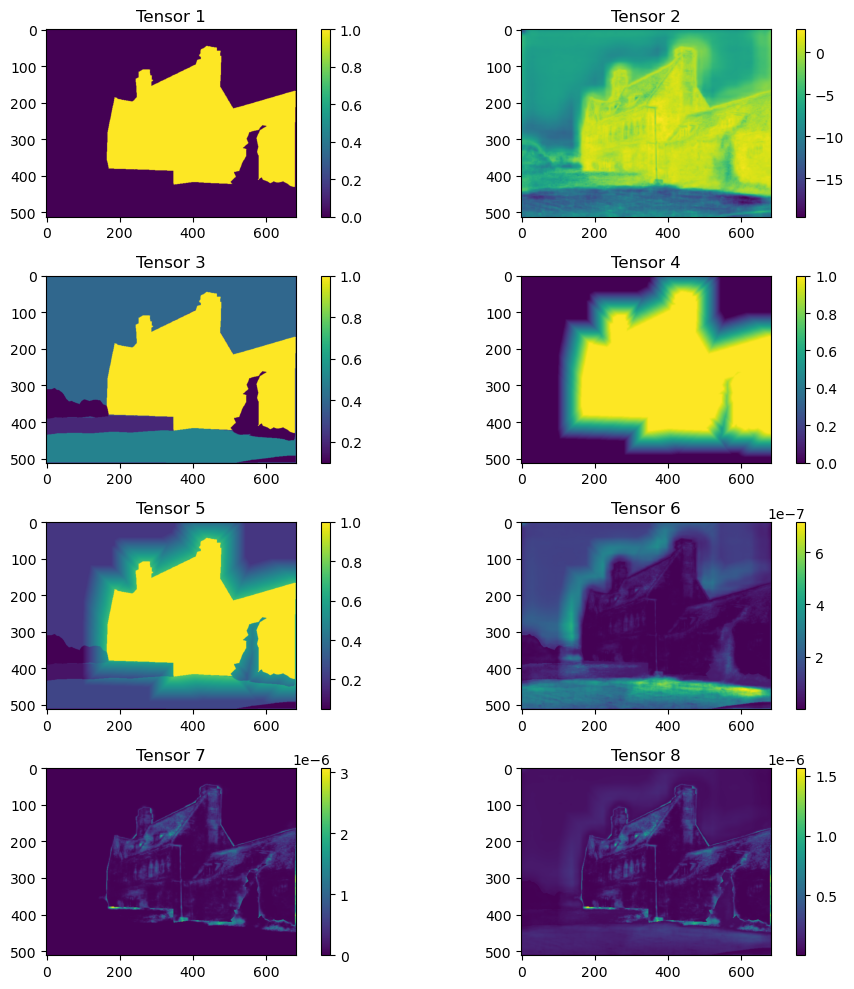

In [52]:
import matplotlib.pyplot as plt

# Plotting the tensors as images
tensor1 = sm == 2
tensor2 = mask[2]
tensor3 = oh_labels[0][2]
tensor4 = rmask[0][2]
tensor5 = labels[0][2]
tensor6 = loss_ce[0][2]
tensor7 = orig_loss[0][2]
tensor8 = loss_final[0][2]

plt.figure(figsize=(10, 10))

# 1 tensor
plt.subplot(4, 2, 1)
plt.imshow(tensor1.cpu().numpy(), cmap='viridis')  # or cmap='gray', etc.
plt.title('Tensor 1')
plt.colorbar()

# 2 tensor
plt.subplot(4, 2, 2)
plt.imshow(tensor2.cpu().numpy(), cmap='viridis')
plt.title('Tensor 2')
plt.colorbar()

# 3 tensor
plt.subplot(4, 2, 3)
plt.imshow(tensor3.cpu().numpy(), cmap='viridis')
plt.title('Tensor 3')
plt.colorbar()

# 4 tensor
plt.subplot(4, 2, 4)
plt.imshow(tensor4.cpu().numpy(), cmap='viridis')
plt.title('Tensor 4')
plt.colorbar()

# 5 tensor
plt.subplot(4, 2, 5)
plt.imshow(tensor5.cpu().numpy(), cmap='viridis')
plt.title('Tensor 5')
plt.colorbar()

# 6 tensor
plt.subplot(4, 2, 6)
plt.imshow(tensor6.cpu().numpy(), cmap='viridis')
plt.title('Tensor 6')
plt.colorbar()

# 7 tensor
plt.subplot(4, 2, 7)
plt.imshow(tensor7.cpu().numpy(), cmap='viridis')
plt.title('Tensor 7')
plt.colorbar()

# 8 tensor
plt.subplot(4, 2, 8)
plt.imshow(tensor8.cpu().numpy(), cmap='viridis')
plt.title('Tensor 8')
plt.colorbar()

plt.tight_layout()

In [ ]:


loss = HierarchicalNACLLoss(in_loss, similarity_matrix):
    """Neighborhood-aware hierarchical loss for geospatial ML."""
    
    def __init__(
        self,
        loss: _Loss,
        similarity_matrix: Optional[Union[List, torch.tensor]] = None,
        temperature: float = 1.0,
        kernel_ops: Optional[Literal["mean", "gaussian"]] = "mean",
        kernel_size: int = 9,
        distance_type: str = "l1",
        alpha: float = 1.0,
        num_classes: Optional[int] = None,
        sigma: float = 1.0,

In [38]:
import rioxarray as rxr

with rxr.open_rasterio(r"E:\Work\CorrProizv\y_spec2.tif", chunks=True, lock=True) as raster:
    y_true = raster.persist()

In [45]:
y_true['band'].values.tolist()

[1]

In [37]:
list(y_true.data_vars)

[1]

In [1]:
import rioxarray as rxr


with rxr.open_rasterio(r"E:\Work\CorrProizv\y_spec2.tif", chunks=True, lock=True) as raster:
    y_true = raster.persist()
with rxr.open_rasterio(r"E:\Work\CorrProizv\y_pred_deeplab.tif", chunks=True, lock=True) as raster:
    y_pred = raster.persist()

In [2]:
import torchmetrics

m = torchmetrics.Accuracy(
    task='multiclass',
    num_classes=13,
    average="micro",
    ignore_index=0,
)

In [3]:
import torch

m(torch.tensor(y_pred.compute().data), torch.tensor(y_true.compute().data))

NameError: name 'm' is not defined

In [74]:
import torchmetrics
import torch

l = torch.nn.CrossEntropyLoss(ignore_index=0)
m = torchmetrics.Accuracy(
    task='multiclass',
    num_classes=4,
    average="macro",
    ignore_index=0,
)

In [75]:
m(torch.tensor([[1, 1, 1, 2, 3]]), torch.tensor([[0, 0, 1, 2, 3]]))

tensor(1.)

In [19]:
l(torch.tensor([[0.5, 0.2, 0.3], [0.1, 0.1, 0.8], [0.1, 0.7, 0.2]]), torch.tensor([0, 0, 0]))

tensor(nan)

In [1]:
import datasets
from torchvision.transforms import v2
from torchvision import tv_tensors

In [2]:
file = "dataset_semantic.rspds/val"

dataset = datasets.Dataset.load_from_disk(file)
dataset.set_format("torch")

# Filtering columns
columns = ["key", "x"]
dataset = dataset.rename_column("y_species", "y")
columns.append("y")
dataset = dataset.select_columns(columns)

Loading dataset from disk:   0%|          | 0/37 [00:00<?, ?it/s]

In [3]:
len(dataset)

2454

In [4]:
def setup_transform(augment):
    input_shape = 256
    x_nodata = 0.0
    y_nodata = 0
    """Setup data augmentation."""
    valid_transforms = [
        "ScaleJitter",
        "RandomResizedCrop",
        "RandomIoUCrop",
        "RandomHorizontalFlip",
        "RandomVerticalFlip",
        "RandomZoomOut",
        "RandomRotation",
        "RandomAffine",
        "RandomPerspective",
        "ElasticTransform",
        "GaussianBlur",
    ]
    if augment is True:
        augment = ("RandomResizedCrop", "RandomHorizontalFlip")
    transforms = []
    if augment is not False:
        for t in augment:
            if isinstance(t, str):
                if t not in valid_transforms:
                    raise ValueError(t + " is not a valid transform")
                if t == "ScaleJitter":
                    transforms.append(v2.ScaleJitter(target_size=(input_shape, input_shape)))
                elif t == "RandomResizedCrop":
                    transforms.append(
                        v2.RandomResizedCrop(size=(input_shape, input_shape), antialias=True),
                    )
                elif t == "RandomIoUCrop":
                    transforms.append(v2.RandomIoUCrop())
                elif t == "RandomHorizontalFlip":
                    transforms.append(v2.RandomHorizontalFlip(p=0.5))
                elif t == "RandomVerticalFlip":
                    transforms.append(v2.RandomVerticalFlip(p=0.5))
                elif t == "RandomZoomOut":
                    transforms.append(
                        v2.RandomZoomOut(fill={tv_tensors.Image: x_nodata, tv_tensors.Mask: y_nodata}),
                    )
                elif t == "RandomRotation":
                    transforms.append(
                        v2.RandomRotation(
                            90,
                            fill={tv_tensors.Image: x_nodata, tv_tensors.Mask: y_nodata},
                        ),
                    )
                elif t == "RandomAffine":
                    transforms.append(
                        v2.RandomAffine(
                            degrees=90,
                            translate=(0.5, 0.5),
                            shear=0.5,
                            fill={tv_tensors.Image: x_nodata, tv_tensors.Mask: y_nodata},
                        ),
                    )
                elif t == "RandomPerspective":
                    transforms.append(
                        v2.RandomPerspective(
                            fill={tv_tensors.Image: self.x_nodata, tv_tensors.Mask: self.y_nodata},
                        ),
                    )
                elif t == "ElasticTransform":
                    transforms.append(
                        v2.ElasticTransform(fill={tv_tensors.Image: x_nodata, tv_tensors.Mask: y_nodata}),
                    )
                elif t == "GaussianBlur":
                    transforms.append(v2.GaussianBlur(kernel_size=(5, 9)))
            else:
                transforms.append(t)

        # Fixing if size has changed or bboxes became invalid after transforms
        transforms.append(v2.Resize(size=(input_shape, input_shape), antialias=True))
        #transforms.append(v2.SanitizeBoundingBoxes(labels_getter=None))
        # Turn tv_tensors back to pure tensors
        transforms.append(v2.ToPureTensor())

        return v2.Compose(transforms)
    return None

In [5]:
transform = setup_transform(True)

def transform_func(data):
    """Apply augmentations to data."""
    data["x"], data["y"] = transform(tv_tensors.Image(data["x"]), tv_tensors.Mask(data["y"]))
    return data

dataset.set_transform(transform_func)

In [7]:
transform

Compose(
      RandomResizedCrop(size=(256, 256), scale=(0.08, 1.0), ratio=(0.75, 1.3333333333333333), interpolation=InterpolationMode.BILINEAR, antialias=True)
      RandomHorizontalFlip(p=0.5)
      Resize(size=[256, 256], interpolation=InterpolationMode.BILINEAR, antialias=True)
      ToPureTensor()
)

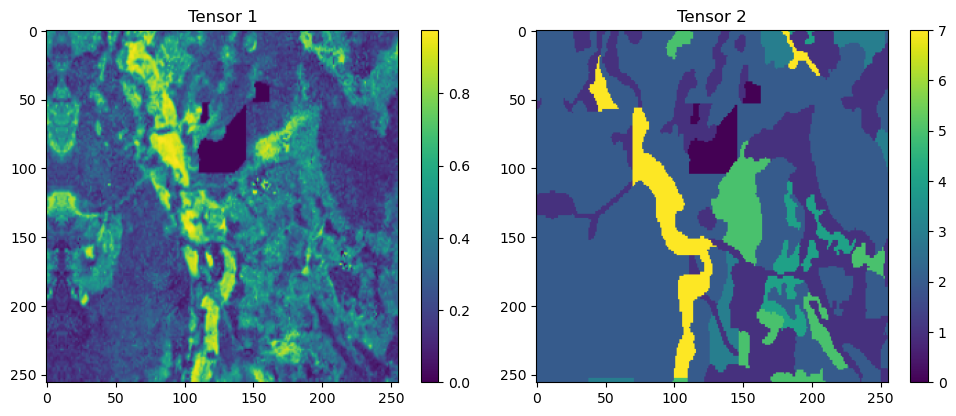

In [8]:
import matplotlib.pyplot as plt

# Plotting the tensors as images
batch = dataset[0]
tensor1 = batch["x"][0]
tensor2 = batch["y"]

plt.figure(figsize=(10, 4))

# First tensor
plt.subplot(1, 2, 1)
plt.imshow(tensor1.numpy(), cmap='viridis')  # or cmap='gray', etc.
plt.title('Tensor 1')
plt.colorbar()

# Second tensor
plt.subplot(1, 2, 2)
plt.imshow(tensor2.numpy(), cmap='viridis')
plt.title('Tensor 2')
plt.colorbar()

plt.tight_layout()
plt.show()